In [13]:
# =============================================================================
# Mapa 2D de los 100 multiplication facts por MDS sobre correlaciones (A998)
# =============================================================================
# PREGUNTA. Si dos operaciones se apoyan en lo mismo (misma tabla, mismo tamaño,
# misma estrategia), los alumnos que aciertan una deberían acertar la otra. Aquí
# se mide eso directamente: cada operación es un vector de 0/1 sobre alumnos, se
# correlacionan todas con todas, la correlación se convierte en distancia y el
# MDS coloca las 100 operaciones en un plano. Las variables "obvias" (tasa de
# error, TR, operandos, tamaño del producto) NO entran en la construcción del
# mapa: solo se usan para colorearlo, así que si el mapa las reproduce es un
# resultado, no una tautología.
#
# DATOS. `queries/a998_student_fact_last_attempt.sql` -> una fila por
# (alumno, factor_1, factor_2) con el resultado de su ÚLTIMA respuesta a esa
# operación (X=1 acierto, X=0 error, decisión de Maria 2026-08-13). Las celdas
# que un alumno nunca vio NO están en la tabla: son huecos, nunca ceros. Cada
# correlación r_ij se calcula solo con los alumnos que respondieron AMBAS
# operaciones (pairwise complete) y se guarda n_ij para saber sobre cuántos
# alumnos se ha calculado. No se elimina a ningún alumno por no tener los 100
# items.
#
# POBLACIÓN. ES_2025, A998, solo multiplicaciones, `statement_idx >= 1`
# (Decisión #7), edades 8-15 en la query y 8-12 en el mapa principal
# (AGES_POOL). Se excluyen las sesiones "racing" (mediana < 1,5 s y accuracy
# < 25%, Decisión #12): un alumno que falla todo es una fila de ceros y hace que
# TODAS las operaciones correlacionen positivamente por un motivo que no es
# aritmético. La celda de estabilidad rehace el mapa sin ese filtro para que se
# vea cuánto cambia.
#
# LO QUE HAY QUE TENER EN LA CABEZA AL LEER EL MAPA (los tres sesgos conocidos):
#   1. El nivel de la tasa de error está inflado: A998 corrige mientras el
#      alumno teclea, así que una primera tecla equivocada ya cuenta como error
#      (suelo mecánico ~20%, no 0). Afecta al nivel, poco al orden.
#   2. Los huecos NO son aleatorios: el pack depende de la edad, así que dos
#      operaciones que viven en packs distintos tienen n_ij pequeño Y se
#      correlacionan sobre una población distinta (alumnos mayores). Por eso hay
#      un chequeo restringido al pack 39, el único que contiene las tablas 0-9.
#   3. Con datos binarios, phi depende de las tasas base, es decir de la
#      dificultad. Parte del gradiente que se verá en el mapa es eso. Se controla
#      repitiendo el MDS con correlación tetracórica (celda 5).
#
# ORIENTACIÓN CONSERVADA: factor_1 x factor_2 en el orden que vio el alumno, así
# que 7x8 y 8x7 son dos puntos distintos y hay exactamente 100 (0-9 x 0-9).
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

HERE = Path.cwd()          # descriptive/ (ejecutar el notebook desde su carpeta)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # raíz del repo -- ahí viven databricks_connector.py y cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query      # SIEMPRE después de sys.path.insert

(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)
CACHE_DIR = HERE / "cache"
SQL_PATH = HERE / "queries" / "a998_student_fact_last_attempt.sql"
PLOTS = HERE / "plots"

# ---- parámetros --------------------------------------------------------------
YEARS = ["ES_2025"]              # Decisión #8
AGE_MIN, AGE_MAX = 8, 15         # Decisión #2 (rango que pide la query)
AGES_POOL = [8, 9, 10, 11, 12]   # edades del mapa principal
AGE_GRADE = {8: "3.º", 9: "4.º", 10: "5.º", 11: "6.º", 12: "1.º ESO"}

EXCLUDE_RACING = True            # Decisión #12; ver cabecera
MIN_STUDENTS_PER_FACT = 200      # una operación con menos alumnos no entra en el mapa
MIN_NIJ = 500                    # por debajo de esto, el par no pesa en el MDS (peso 0)
DIST_FORM = "sqrt(2(1-r))"             # d_ij pedida; alternativa métrica: "sqrt(2(1-r))"
WEIGHTS = "nij"                  # peso de cada par en el SMACOF: "nij" o "uniform"
N_COMPONENTS = 2
N_INIT, MAX_ITER, SEED = 12, 800, 20260813

RUN_RACING_CHECK = True          # rehace el mapa sin filtrar racing (1 query más)
RUN_PACK39_CHECK = True          # rehace el mapa solo con pack 39 (1 query más)
RUN_HEATMAP_CROSSCHECK = True    # compara la tasa de error con a998_fact_heatmap_by_age

# ---- estilo ------------------------------------------------------------------
# Fuente: la primera de la lista que esté instalada de verdad (pedir Helvetica a
# ciegas deja un warning y un fallback silencioso). Arial y Liberation/Nimbus
# Sans son metric-compatibles con Helvetica.
FONT_PREF = ["Helvetica", "Helvetica Neue", "Arial", "Liberation Sans",
             "Nimbus Sans", "Calibri", "DejaVu Sans"]
_installed = {f.name for f in mpl.font_manager.fontManager.ttflist}
FONT = next((f for f in FONT_PREF if f in _installed), "DejaVu Sans")
FONT_BASE = 12
mpl.rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none",   # texto editable
                     "font.family": FONT,
                     "font.size": FONT_BASE,
                     "axes.titlesize": FONT_BASE + 1,
                     "axes.labelsize": FONT_BASE,
                     "xtick.labelsize": FONT_BASE - 1,
                     "ytick.labelsize": FONT_BASE - 1,
                     "legend.fontsize": FONT_BASE - 1,
                     "figure.dpi": 110,
                     "savefig.bbox": "tight"})
print(f"fuente: {FONT}")


# ---- carga -------------------------------------------------------------------
def load_last_attempts(exclude_racing: bool, pack: int | None = None) -> pd.DataFrame:
    """Reescribe los marcadores del .sql y lo ejecuta (cache por texto ejecutado).

    Cada re.subn comprueba que ha sustituido exactamente una vez: si un marcador
    se mueve o se renombra, esto revienta aquí en lugar de consultar en silencio
    una población distinta.
    """
    sql_raw = SQL_PATH.read_text(encoding="utf-8")
    years_sql = ", ".join(f"'{y}'" for y in YEARS)

    sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", sql_raw)
    sql_text, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                            f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql_text)
    pack_clause = "1 = 1" if pack is None else f"s.activity_pack = {pack}"
    sql_text, n_p = re.subn(r"AND [^\n]*?(\s*-- \{PACKS\})", f"AND {pack_clause}\\1", sql_text)
    racing_clause = "racing_sitting = 0" if exclude_racing else "1 = 1"
    sql_text, n_r = re.subn(r"WHERE 1 = 1(\s*-- \{RACING_FILTER\})",
                            f"WHERE {racing_clause}\\1", sql_text)
    assert (n_y, n_a, n_p, n_r) == (1, 1, 1, 1), \
        f"marcadores sustituidos {(n_y, n_a, n_p, n_r)}, esperaba (1, 1, 1, 1)"

    df = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)
    for c in ("student_idx", "student_age", "n_ages", "n_statements", "factor_1",
              "factor_2", "product", "is_correct", "racing_sitting", "activity_pack",
              "n_attempts", "n_correct_all"):
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df


att = load_last_attempts(EXCLUDE_RACING)

# ---- de dónde salen los datos (Decisión #3: contarlo junto a cada figura) -----
n_stu = att["student_idx"].nunique()
n_facts_seen = att.groupby(["factor_1", "factor_2"]).ngroups
print(f"\nA998 · {'+'.join(YEARS)} · multiplicaciones · statement_idx >= 1 · "
      f"edades {AGE_MIN}-{AGE_MAX} · racing {'EXCLUIDO' if EXCLUDE_RACING else 'incluido'}")
print(f"filas (alumno x operación): {len(att):,}".replace(",", "."))
print(f"alumnos: {n_stu:,}".replace(",", ".") + f" · operaciones distintas: {n_facts_seen}")
print(f"operaciones por alumno: mediana {att.groupby('student_idx').size().median():.0f}, "
      f"media {att.groupby('student_idx').size().mean():.1f}")
print(f"intentos por celda: 1 en el {100 * (att['n_attempts'] == 1).mean():.1f}% de las celdas, "
      f"máximo {att['n_attempts'].max()}")
print(f"aciertos (última respuesta): {100 * att['is_correct'].mean():.1f}%")

# controles de integridad de la query, no formalidades
assert att["factor_1"].between(0, 9).all() and att["factor_2"].between(0, 9).all(), \
    "hay operandos fuera de 0-9: la query no está devolviendo solo multiplicaciones de un dígito"
assert not att.duplicated(["student_idx", "factor_1", "factor_2"]).any(), \
    "hay más de una fila por (alumno, operación): el ROW_NUMBER de la query no está aislando la última"
if EXCLUDE_RACING:
    assert (att["racing_sitting"] == 0).all(), "el filtro de racing no se ha aplicado"
multi_age = att.loc[att["n_ages"] > 1, "student_idx"].nunique()
print(f"alumnos con más de una edad en el año: {multi_age} "
      f"({100 * multi_age / n_stu:.2f}%; se les asigna la edad de su sesión más reciente)")
print("packs presentes:", sorted(att["activity_pack"].unique()))


fuente: Arial

A998 · ES_2025 · multiplicaciones · statement_idx >= 1 · edades 8-15 · racing EXCLUIDO
filas (alumno x operación): 3.732.824
alumnos: 166.903 · operaciones distintas: 100
operaciones por alumno: mediana 21, media 22.4
intentos por celda: 1 en el 87.4% de las celdas, máximo 6
aciertos (última respuesta): 82.2%
alumnos con más de una edad en el año: 0 (0.00%; se les asigna la edad de su sesión más reciente)
packs presentes: [np.int8(14), np.int8(16), np.int8(20), np.int8(39)]


In [14]:
# =============================================================================
# 1. Matriz alumno x operación y correlaciones pairwise-complete
# =============================================================================
# X tiene una fila por alumno y una columna por operación, con NaN donde el
# alumno no vio la operación. NaN significa "no observado" y nada más: no se
# imputa, no se rellena con 0 y no se descarta a nadie por tener huecos.
#
# CÓMO SE CALCULA r_ij SIN BUCLES. Con M = máscara de observado (1/0) y
# Z = X con los NaN puestos a 0 (que es inocuo porque solo aparece dentro de
# sumas), todo sale de cuatro productos de matrices:
#     n_ij  = M'M           alumnos que respondieron ambas
#     S11   = Z'Z           de ellos, cuántos acertaron las dos
#     Si    = Z'M           suma de x_i sobre esos alumnos
#     Sj    = M'Z           suma de x_j sobre esos alumnos
# y como x es binaria, sum(x^2) = sum(x), así que
#     cov = S11/n - (Si/n)(Sj/n),  var_i = Si/n - (Si/n)^2
#     r   = cov / sqrt(var_i var_j)
# Esto es EXACTAMENTE la r de Pearson par a par (= coeficiente phi para datos
# binarios), calculada sobre los casos completos de cada par, no una
# aproximación. Con 100 columnas son cuatro productos de 100x100: instantáneo.
# La celda de verificación de abajo lo comprueba contra el cálculo par-a-par.

FACTS = [(a, b) for a in range(10) for b in range(10)]      # 100, orden conservado
FACT_LABEL = {f: f"{f[0]}×{f[1]}" for f in FACTS}


def build_matrix(df: pd.DataFrame, ages=None):
    """Devuelve (X, facts, students) con X de tamaño alumnos x operaciones y NaN
    en las celdas no observadas. `ages` filtra por la edad del alumno."""
    d = df if ages is None else df[df["student_age"].isin(ages)]
    stu_codes, students = pd.factorize(d["student_idx"].to_numpy())
    fact_key = (d["factor_1"] * 10 + d["factor_2"]).to_numpy()
    col_of = {a * 10 + b: k for k, (a, b) in enumerate(FACTS)}
    fact_codes = np.array([col_of[k] for k in fact_key], dtype=int)

    X = np.full((len(students), len(FACTS)), np.nan, dtype=np.float32)
    X[stu_codes, fact_codes] = pd.to_numeric(d["is_correct"]).to_numpy(dtype=np.float32)
    return X, list(FACTS), students


def phi_pairwise(X: np.ndarray):
    """(R, N): correlación de Pearson par a par con casos completos, y n_ij."""
    M = (~np.isnan(X)).astype(np.float64)
    Z = np.nan_to_num(X, nan=0.0).astype(np.float64)

    N = M.T @ M                       # n_ij
    S11 = Z.T @ Z
    Si = Z.T @ M                      # sum x_i sobre los pares completos
    Sj = Si.T                         # = M'Z
    with np.errstate(invalid="ignore", divide="ignore"):
        pi, pj, p11 = Si / N, Sj / N, S11 / N
        cov = p11 - pi * pj
        vi, vj = pi * (1 - pi), pj * (1 - pj)
        R = cov / np.sqrt(vi * vj)
    R[N < 3] = np.nan                 # con 2 alumnos una correlación no existe
    np.fill_diagonal(R, 1.0)
    return R, N


def cell_counts(X: np.ndarray):
    """Las cuatro celdas de la tabla 2x2 de cada par (n11, n10, n01, n00) y n_ij.
    Las necesita la correlación tetracórica de la celda 5."""
    M = (~np.isnan(X)).astype(np.float64)
    Z = np.nan_to_num(X, nan=0.0).astype(np.float64)
    N = M.T @ M
    n11 = Z.T @ Z
    Si = Z.T @ M
    Sj = Si.T
    n10 = Si - n11                    # i acierta, j falla
    n01 = Sj - n11
    n00 = N - n11 - n10 - n01
    return n11, n10, n01, n00, N


X_all, facts_all, students_all = build_matrix(att, AGES_POOL)
R_raw, N_raw = phi_pairwise(X_all)
print(f"matriz: {X_all.shape[0]:,}".replace(",", ".") + f" alumnos x {X_all.shape[1]} operaciones")
print(f"celdas observadas: {100 * np.mean(~np.isnan(X_all)):.1f}% "
      f"({np.sum(~np.isnan(X_all)):,}".replace(",", ".") + " respuestas)")

# --- verificación: la fórmula matricial contra el cálculo par a par ------------
rng_check = np.random.default_rng(0)
sub_rows = rng_check.choice(X_all.shape[0], size=min(3000, X_all.shape[0]), replace=False)
sub_cols = rng_check.choice(X_all.shape[1], size=12, replace=False)
Xs = X_all[np.ix_(sub_rows, sub_cols)]
Rs, Ns = phi_pairwise(Xs)
worst = 0.0
for i in range(len(sub_cols)):
    for j in range(len(sub_cols)):
        ok = ~np.isnan(Xs[:, i]) & ~np.isnan(Xs[:, j])
        a, b = Xs[ok, i], Xs[ok, j]
        assert ok.sum() == Ns[i, j], "n_ij no coincide con los casos completos"
        if ok.sum() >= 3 and a.std() > 0 and b.std() > 0:
            ref = np.corrcoef(a.astype(float), b.astype(float))[0, 1]
            worst = max(worst, abs(ref - Rs[i, j]))
print(f"verificación phi (fórmula matricial vs par a par, 12 operaciones): "
      f"diferencia máxima {worst:.2e}")
assert worst < 1e-9, "la fórmula matricial no reproduce la correlación par a par"

# --- ¿depende de la regla de agregación? (última vs mayoría vs todas) ----------
# La query trae n_attempts y n_correct_all justo para poder responder esto sin
# volver al warehouse. Si las tres reglas dan casi la misma matriz, la elección
# de "última respuesta" no está sosteniendo el resultado.
alt = att[att["student_age"].isin(AGES_POOL)].copy()
alt["maj"] = (alt["n_correct_all"] / alt["n_attempts"] > 0.5).astype(np.float32)
alt["allc"] = (alt["n_correct_all"] == alt["n_attempts"]).astype(np.float32)
R_alts = {}
for rule, col in (("mayoría", "maj"), ("todas correctas", "allc")):
    tmp = alt.rename(columns={"is_correct": "_last", col: "is_correct"})
    Xr, _, _ = build_matrix(tmp, AGES_POOL)
    R_alts[rule], _ = phi_pairwise(Xr)
    m = np.isfinite(R_raw) & np.isfinite(R_alts[rule]) & ~np.eye(len(FACTS), dtype=bool)
    print(f"regla '{rule}' vs 'última respuesta': r entre las dos matrices de "
          f"correlación = {np.corrcoef(R_raw[m], R_alts[rule][m])[0, 1]:.3f}, "
          f"diferencia media |Δr| = {np.mean(np.abs(R_raw[m] - R_alts[rule][m])):.3f}")


matriz: 147.568 alumnos x 100 operaciones
celdas observadas: 21.6% (3.183.256 respuestas)
verificación phi (fórmula matricial vs par a par, 12 operaciones): diferencia máxima 3.33e-15
regla 'mayoría' vs 'última respuesta': r entre las dos matrices de correlación = 0.991, diferencia media |Δr| = 0.007
regla 'todas correctas' vs 'última respuesta': r entre las dos matrices de correlación = 0.989, diferencia media |Δr| = 0.007


tasa de error: media no ponderada por edad vs pooled bruto, r = 0.974
edades que entran en la media (por operación): 4 edad(es): 28 ops, 5 edad(es): 72 ops

operaciones con >= 200 alumnos: 100 de 100
alumnos por operación: mín 18.167 · mediana 31.266 · máx 49.002

n_ij (alumnos compartidos por par): mín 4.392 · P25 4.968 · mediana 9.106 · máx 24.469
  pares con n_ij <    100:   0.0%
  pares con n_ij <    500:   0.0%
  pares con n_ij <  2.000:   0.0%
  pares con n_ij < 10.000:  64.6%
pares sin r calculable (n_ij < 3): 0
n_ij mediano. pares 'ninguna 0/1': 10.703  (r mediana +0.279)
n_ij mediano. pares 'una 0/1': 5.018  (r mediana +0.162)
n_ij mediano. pares 'ambas 0/1': 4.645  (r mediana +0.161)


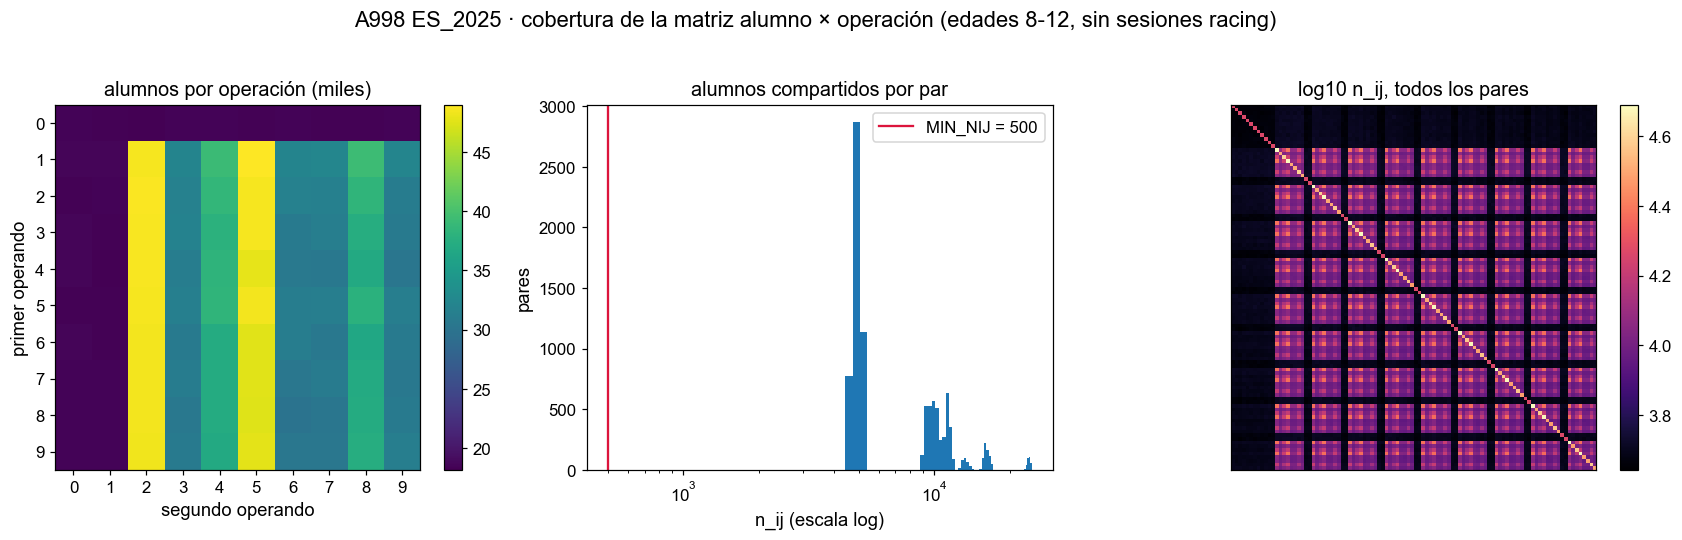

In [15]:
# =============================================================================
# 2. Cobertura: cuántos alumnos por operación y cuántos compartidos por par
# =============================================================================
# Esta celda es la que decide qué correlaciones son creíbles. Dos cosas:
#   (a) n de cada operación -> qué operaciones entran en el mapa.
#   (b) n_ij de cada par    -> cuánto pesa ese par en el MDS (los pares con
#       n_ij < MIN_NIJ pesan 0; no se inventa un valor para ellos).
# El reparto de n_ij NO es aleatorio: el pack depende de la edad, y solo el pack
# 39 contiene las tablas 0-9, así que las operaciones con 0 o 1 solo las ven los
# alumnos de 9 años (T3) en adelante. Es decir, los pares "dentro del mismo pack"
# se estiman sobre muchos alumnos y los pares "entre packs" sobre menos alumnos Y
# más mayores. Esto se mira aquí y se vuelve a atacar en la celda 4 con el
# chequeo restringido al pack 39.

pool = att[att["student_age"].isin(AGES_POOL)]

# --- estadísticos por operación (solo para colorear e interpretar) -------------
g = pool.groupby(["factor_1", "factor_2"])
fact_stats = pd.DataFrame({
    "n_students": g.size(),
    "err_pooled": 1 - g["is_correct"].mean(),
    "median_rt": g.apply(lambda d: d.loc[d["is_correct"] == 1, "rt_seconds"].median(),
                         include_groups=False),
}).reset_index()

# Media NO ponderada de las tasas por edad (convención del póster): la composición
# de los packs cambia con la edad, y las edades pequeñas aportan a la vez más
# intentos y más error, así que ponderar por n promociona lo que se practica a los
# 8. Se promedian solo las edades con al menos 50 alumnos en esa operación, y se
# guarda cuántas edades han entrado, porque las operaciones con 0 o 1 no existen
# a los 8 años y su media se apoya en menos edades.
by_age = (pool.groupby(["factor_1", "factor_2", "student_age"])
              .agg(n=("is_correct", "size"), err=("is_correct", lambda s: 1 - s.mean()))
              .reset_index())
by_age = by_age[by_age["n"] >= 50]
age_avg = (by_age.groupby(["factor_1", "factor_2"])
                 .agg(err_ageavg=("err", "mean"), n_ages_used=("err", "size"))
                 .reset_index())
fact_stats = fact_stats.merge(age_avg, on=["factor_1", "factor_2"], how="left")
fact_stats["product"] = fact_stats["factor_1"] * fact_stats["factor_2"]
fact_stats["label"] = [FACT_LABEL[(a, b)] for a, b in
                       zip(fact_stats["factor_1"], fact_stats["factor_2"])]
_m = fact_stats["err_ageavg"].notna()
print(f"tasa de error: media no ponderada por edad vs pooled bruto, "
      f"r = {fact_stats.loc[_m, ['err_ageavg', 'err_pooled']].corr().iloc[0, 1]:.3f}")
print("edades que entran en la media (por operación): " +
      ", ".join(f"{k} edad(es): {v} ops" for k, v in
                fact_stats["n_ages_used"].fillna(0).astype(int).value_counts().sort_index().items()))

# --- qué operaciones entran en el mapa ----------------------------------------
n_stu_fact = np.array([fact_stats.set_index(["factor_1", "factor_2"])["n_students"].get(f, 0)
                       for f in FACTS], dtype=float)
KEEP = n_stu_fact >= MIN_STUDENTS_PER_FACT
dropped = [FACT_LABEL[f] for f, k in zip(FACTS, KEEP) if not k]
print(f"\noperaciones con >= {MIN_STUDENTS_PER_FACT} alumnos: {KEEP.sum()} de 100")
if dropped:
    print("fuera del mapa por falta de alumnos:", ", ".join(dropped))

# Segunda condición, y no es una formalidad: una operación que no comparte
# MIN_NIJ alumnos con NINGUNA otra no tiene ni una distancia que la sujete, y el
# MDS la colocaría en un sitio arbitrario. Se saca del mapa y se dice cuál.
_well = (N_raw >= MIN_NIJ) & ~np.eye(len(FACTS), dtype=bool)
while True:                          # quitar una puede aislar otra: se repite
    _isolated = KEEP & (_well[:, KEEP].sum(axis=1) == 0)
    if not _isolated.any():
        break
    print(f"fuera del mapa por no compartir {MIN_NIJ} alumnos con ninguna otra "
          "operación:", ", ".join(FACT_LABEL[f] for f, k in zip(FACTS, _isolated) if k))
    KEEP = KEEP & ~_isolated
print(f"alumnos por operación: mín {n_stu_fact[KEEP].min():,.0f}".replace(",", ".") +
      f" · mediana {np.median(n_stu_fact[KEEP]):,.0f}".replace(",", ".") +
      f" · máx {n_stu_fact[KEEP].max():,.0f}".replace(",", "."))

facts = [f for f, k in zip(FACTS, KEEP) if k]
labels = [FACT_LABEL[f] for f in facts]
R = R_raw[np.ix_(KEEP, KEEP)].copy()
N = N_raw[np.ix_(KEEP, KEEP)].copy()
nf = len(facts)
off = ~np.eye(nf, dtype=bool)

# --- n_ij ---------------------------------------------------------------------
nij = N[off]
print(f"\nn_ij (alumnos compartidos por par): mín {nij.min():,.0f}".replace(",", ".") +
      f" · P25 {np.percentile(nij, 25):,.0f}".replace(",", ".") +
      f" · mediana {np.median(nij):,.0f}".replace(",", ".") +
      f" · máx {nij.max():,.0f}".replace(",", "."))
for thr in (100, 500, 2000, 10000):
    print(f"  pares con n_ij < {thr:>6,}".replace(",", ".") +
          f": {100 * np.mean(nij < thr):5.1f}%")
print(f"pares sin r calculable (n_ij < 3): {int(np.sum(~np.isfinite(R[off])))}")

# ¿el hueco es estructural? comparación de n_ij según si la operación es de las
# que solo aparecen en el pack 39 (algún operando 0 o 1)
p39_only = np.array([(a <= 1) or (b <= 1) for a, b in facts])
pair_kind = np.where(p39_only[:, None] & p39_only[None, :], "ambas 0/1",
                     np.where(p39_only[:, None] | p39_only[None, :], "una 0/1", "ninguna 0/1"))
for kind in ("ninguna 0/1", "una 0/1", "ambas 0/1"):
    sel = (pair_kind == kind) & off
    if sel.any():
        print(f"n_ij mediano, pares '{kind}': {np.median(N[sel]):,.0f}".replace(",", ".") +
              f"  (r mediana {np.nanmedian(R[sel]):+.3f})")

# --- figura de cobertura ------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

grid = np.full((10, 10), np.nan)
for (a, b), v in zip(FACTS, n_stu_fact):
    grid[a, b] = v if v > 0 else np.nan
im = axes[0].imshow(grid / 1000, cmap="viridis", origin="upper")
axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
axes[0].set_xlabel("segundo operando"); axes[0].set_ylabel("primer operando")
axes[0].set_title("alumnos por operación (miles)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].hist(nij, bins=60)
axes[1].set_xscale("log")
axes[1].axvline(MIN_NIJ, color="crimson", lw=1.5,
                label=f"MIN_NIJ = {MIN_NIJ}")
axes[1].set_xlabel("n_ij (escala log)"); axes[1].set_ylabel("pares")
axes[1].set_title("alumnos compartidos por par")
axes[1].legend()

im2 = axes[2].imshow(np.log10(np.maximum(N, 1)), cmap="magma")
axes[2].set_title("log10 n_ij, todos los pares")
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("A998 ES_2025 · cobertura de la matriz alumno × operación "
             f"(edades {min(AGES_POOL)}-{max(AGES_POOL)}, "
             f"{'sin' if EXCLUDE_RACING else 'con'} sesiones racing)", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_cobertura.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_cobertura.pdf")
plt.show()

d_ij = sqrt(2(1-r)) · pesos = nij · MIN_NIJ = 500 · 100 operaciones · 4.950 pares con peso de 4950
stress-1 (Kruskal, denominador = distancias del mapa): 0.4276
stress-1 (sklearn, denominador = disparidades):        0.3931
correlación entre distancia del mapa y d_ij objetivo:  0.502
autovalores (MDS clásico), 5 primeros: [5.39 2.9  2.35 1.4  1.25] · más negativo 0.00
  varianza explicada por 2 dimensiones (solo autovalores positivos): 10.7%
autovalor mínimo de la matriz de correlaciones: +0.376 (positivo: la matriz estimada par a par sigue siendo semidefinida positiva)
stress-1 por número de dimensiones: 1D 0.681 · 2D 0.428 · 3D 0.320 · 4D 0.258 · 5D 0.220
sklearn no instalado: se salta la comprobación cruzada del SMACOF (el mapa no lo necesita, solo la verificación)


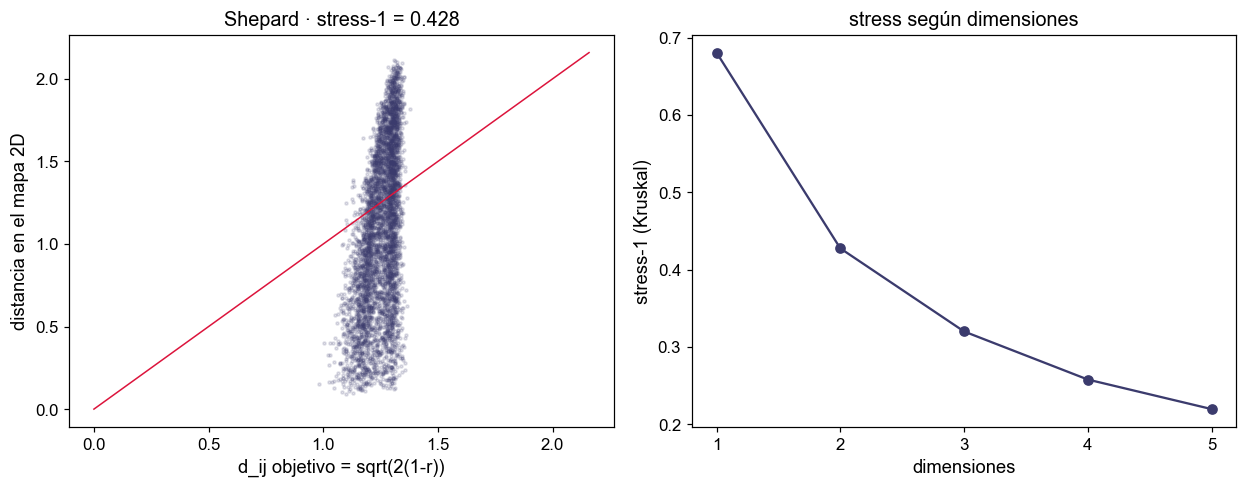

In [16]:
# =============================================================================
# 3. De correlación a distancia, y MDS (SMACOF ponderado por n_ij)
# =============================================================================
# DISTANCIA. d_ij = 2(1 - r_ij), la que pediste: 0 si las dos operaciones se
# comportan igual, 2 si son independientes, 4 si son opuestas. Se guarda también
# la variante métrica sqrt(2(1-r)) -- que es literalmente la distancia euclídea
# entre las dos columnas estandarizadas -- porque es la única de las dos que un
# plano puede reproducir de forma exacta cuando la estructura es de baja
# dimensión; la celda 4 compara los dos mapas.
#
# PESOS. El SMACOF de sklearn no acepta pesos, así que aquí va implementado (30
# líneas de numpy, transformación de Guttman con la pseudoinversa de V). Importa
# por dos motivos:
#   - un par con n_ij = 300 y otro con n_ij = 60.000 no merecen la misma
#     influencia sobre el mapa: el peso w_ij = n_ij es el que le corresponde a
#     una r cuya varianza va como 1/n;
#   - los pares con n_ij < MIN_NIJ entran con peso 0, que es la forma correcta de
#     decir "no lo sé" (mejor que imputar una distancia media, que es inventar).
# La celda de verificación comprueba que con pesos uniformes reproduce el SMACOF
# de sklearn, y la celda 4 rehace el mapa con pesos uniformes para ver si los
# pesos están sosteniendo algo.
#
# STRESS. Se dan las dos normalizaciones porque circulan las dos y no valen lo
# mismo: stress-1 de Kruskal divide por las distancias AJUSTADAS (las del mapa),
# y `normalized_stress` de sklearn divide por las disparidades (las de entrada).
# Los umbrales clásicos de Kruskal (0,20 pobre / 0,10 aceptable / 0,05 bueno) se
# formularon para MDS no métrico sobre matrices completas; aquí son una
# referencia, no un veredicto.

R_clip = np.clip(R, -1.0, 1.0)


def dist_from_r(Rm, form=DIST_FORM):
    if form == "2(1-r)":
        return 2.0 * (1.0 - Rm)
    if form == "sqrt(2(1-r))":
        return np.sqrt(2.0 * (1.0 - Rm))
    raise ValueError(form)


def weights_from_n(Nm, min_nij=MIN_NIJ, mode=WEIGHTS):
    W = np.asarray(Nm, dtype=float).copy()
    if mode == "uniform":
        W = (W >= min_nij).astype(float)
    elif mode == "nij":
        W[W < min_nij] = 0.0
    else:
        raise ValueError(mode)
    np.fill_diagonal(W, 0.0)
    return W


def prepare(Rm, Nm, form=DIST_FORM, min_nij=MIN_NIJ, mode=WEIGHTS):
    """(D, W) listos para el SMACOF: los pares sin r o con poco n_ij pesan 0."""
    D = dist_from_r(np.clip(Rm, -1, 1), form)
    W = weights_from_n(Nm, min_nij, mode)
    W[~np.isfinite(D)] = 0.0
    D = np.where(np.isfinite(D), D, 0.0)
    np.fill_diagonal(D, 0.0)
    if not (W > 0).any():
        raise ValueError(f"ningún par supera MIN_NIJ = {min_nij}: baja el umbral "
                         "(la celda 2 imprime la distribución de n_ij)")
    return D, W


def isolated_facts(W):
    """Operaciones sin ni un par con peso: el MDS no las puede colocar."""
    return np.where(W.sum(axis=1) == 0)[0]


def classical_mds(D, W=None, n_components=2):
    """Torgerson: sirve de punto de partida del SMACOF y da el espectro, que es
    un diagnóstico por sí mismo (autovalores negativos grandes = la matriz de
    distancias no es euclídea, algo esperable con correlaciones pairwise)."""
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, V = np.linalg.eigh((B + B.T) / 2)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    pos = np.maximum(w[:n_components], 0)
    Y = V[:, :n_components] * np.sqrt(pos)
    return Y, w


def smacof_weighted(D, W, n_components=2, n_init=N_INIT, max_iter=MAX_ITER,
                    eps=1e-10, seed=SEED, init=None):
    """SMACOF con pesos (Borg & Groenen). Minimiza sum_{i<j} w_ij (dist_ij - d_ij)^2
    por transformación de Guttman: X <- V^+ B(X) X."""
    D = (D + D.T) / 2.0
    W = (W + W.T) / 2.0
    np.fill_diagonal(D, 0.0)
    np.fill_diagonal(W, 0.0)
    n = D.shape[0]

    V = -W.copy()
    np.fill_diagonal(V, W.sum(axis=1))
    Vp = np.linalg.pinv(V)

    scale = np.sqrt(np.average(D[W > 0] ** 2)) if (W > 0).any() else 1.0
    rng = np.random.default_rng(seed)
    starts = []
    if init is not None:
        starts.append(np.asarray(init, dtype=float)[:, :n_components])
    while len(starts) < max(n_init, 1):
        starts.append(rng.normal(scale=scale / np.sqrt(n_components), size=(n, n_components)))

    best = None
    for X in starts:
        X = np.asarray(X, dtype=float) - np.asarray(X, dtype=float).mean(axis=0)
        prev = np.inf
        for _ in range(max_iter):
            diff = X[:, None, :] - X[None, :, :]
            dist = np.sqrt((diff ** 2).sum(-1))
            raw = 0.5 * float((W * (dist - D) ** 2).sum())
            if prev - raw < eps * max(raw, 1e-12):
                prev = raw
                break
            prev = raw
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = np.where(dist > 1e-12, W * D / np.maximum(dist, 1e-12), 0.0)
            B = -ratio
            np.fill_diagonal(B, 0.0)
            np.fill_diagonal(B, -B.sum(axis=1))
            X = Vp @ (B @ X)
            X -= X.mean(axis=0)
        if best is None or prev < best[0]:
            best = (prev, X)
    return best[1], best[0]


def stress_metrics(D, W, Y):
    diff = Y[:, None, :] - Y[None, :, :]
    dist = np.sqrt((diff ** 2).sum(-1))
    up = np.triu(np.ones_like(D, dtype=bool), 1)
    w, d_fit, d_tgt = W[up], dist[up], D[up]
    raw = float(np.sum(w * (d_fit - d_tgt) ** 2))
    if not (w > 0).any():
        raise ValueError("ningún par tiene peso: MIN_NIJ es demasiado alto para "
                         "esta población (mira el histograma de n_ij de la celda 2)")
    return {
        "raw": raw,
        "stress1_kruskal": float(np.sqrt(raw / np.sum(w * d_fit ** 2))),
        "stress1_sklearn": float(np.sqrt(raw / np.sum(w * d_tgt ** 2))),
        "r_fit_target": float(np.corrcoef(d_fit[w > 0], d_tgt[w > 0])[0, 1]),
    }, dist


D, W = prepare(R, N)
Y0, eig = classical_mds(D, n_components=N_COMPONENTS)
Y, raw_stress = smacof_weighted(D, W, N_COMPONENTS, init=Y0)
met, dist_fit = stress_metrics(D, W, Y)

print(f"d_ij = {DIST_FORM} · pesos = {WEIGHTS} · MIN_NIJ = {MIN_NIJ} · "
      f"{nf} operaciones · {int((W > 0).sum() / 2):,}".replace(",", ".") +
      f" pares con peso de {nf * (nf - 1) // 2}")
print(f"stress-1 (Kruskal, denominador = distancias del mapa): {met['stress1_kruskal']:.4f}")
print(f"stress-1 (sklearn, denominador = disparidades):        {met['stress1_sklearn']:.4f}")
print(f"correlación entre distancia del mapa y d_ij objetivo:  {met['r_fit_target']:.3f}")
print(f"autovalores (MDS clásico), 5 primeros: "
      f"{np.array2string(eig[:5], precision=2)} · "
      f"más negativo {eig.min():.2f}")
print(f"  varianza explicada por 2 dimensiones (solo autovalores positivos): "
      f"{100 * eig[:2].sum() / eig[eig > 0].sum():.1f}%")
_ev = np.linalg.eigvalsh(np.where(np.isfinite(R_clip), R_clip, 0.0))
print(f"autovalor mínimo de la matriz de correlaciones: {_ev.min():+.3f} " +
      ("(negativo: la matriz estimada par a par no es semidefinida positiva. Es lo "
       "esperable al borrar por pares -- cada celda se estima sobre una muestra "
       "distinta -- y no un error; solo significa que no existe ningún conjunto de "
       "vectores que reproduzca exactamente estas correlaciones)"
       if _ev.min() < 0 else
       "(positivo: la matriz estimada par a par sigue siendo semidefinida positiva)"))

# --- ¿cuántas dimensiones? ----------------------------------------------------
scree = {}
for k in (1, 2, 3, 4, 5):
    Yk, _ = smacof_weighted(D, W, k, n_init=max(4, N_INIT // 3),
                            init=classical_mds(D, n_components=k)[0])
    scree[k] = stress_metrics(D, W, Yk)[0]["stress1_kruskal"]
print("stress-1 por número de dimensiones: " +
      " · ".join(f"{k}D {v:.3f}" for k, v in scree.items()))

# --- verificación: con pesos uniformes debe coincidir con sklearn --------------
try:
    from sklearn.manifold import smacof as sk_smacof
    Du = D.copy()
    Wu = np.ones_like(D)
    np.fill_diagonal(Wu, 0.0)
    Ym, _ = smacof_weighted(Du, Wu, 2, n_init=1, init=classical_mds(Du)[0], max_iter=2000)
    Ysk, sk_stress = sk_smacof(Du, n_components=2, metric=True, n_init=1,
                               init=classical_mds(Du)[0], max_iter=2000,
                               random_state=0, eps=1e-12, normalized_stress=False)
    mine = 0.5 * float((Wu * (np.sqrt(((Ym[:, None] - Ym[None]) ** 2).sum(-1)) - Du) ** 2).sum())
    print(f"verificación SMACOF (pesos uniformes): stress propio {mine:.6f} vs "
          f"sklearn {sk_stress:.6f} · diferencia relativa "
          f"{abs(mine - sk_stress) / max(sk_stress, 1e-12):.2e}")
except ImportError:
    print("sklearn no instalado: se salta la comprobación cruzada del SMACOF "
          "(el mapa no lo necesita, solo la verificación)")

# --- diagrama de Shepard ------------------------------------------------------
up = np.triu(np.ones_like(D, dtype=bool), 1)
sel = up & (W > 0)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].scatter(D[sel], dist_fit[sel], s=4, alpha=0.15, color="#3b3b6d")
lim = [0, max(D[sel].max(), dist_fit[sel].max()) * 1.02]
axes[0].plot(lim, lim, color="crimson", lw=1)
axes[0].set_xlabel(f"d_ij objetivo = {DIST_FORM}")
axes[0].set_ylabel("distancia en el mapa 2D")
axes[0].set_title(f"Shepard · stress-1 = {met['stress1_kruskal']:.3f}")

axes[1].plot(list(scree), [scree[k] for k in scree], marker="o", color="#3b3b6d")
axes[1].set_xlabel("dimensiones"); axes[1].set_ylabel("stress-1 (Kruskal)")
axes[1].set_xticks(list(scree))
axes[1].set_title("stress según dimensiones")
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_stress.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_stress.pdf")
plt.show()

verificación Procrustes: propio 0.001707 vs scipy 0.001707
MIN_NIJ = 25000: ningún par lo supera, se salta

mitades: disparidad 0.3780 (mín 0.3318, máx 0.4380) con MIN_NIJ reescalado a 250 y 100 operaciones

racing incluido: 152.065 alumnos (vs 147.568 filtrados) · r mediana entre pares +0.528 vs +0.203 filtrado
  (si la r mediana sube al incluirlos es exactamente el artefacto que el filtro evita: una fila de ceros correlaciona todo con todo)

pack 39: 101.990 alumnos · celdas observadas 17.7% (vs 21.6% con todos los packs) · n_ij mediano 4.402 · MIN_NIJ reescalado a 346

--- estabilidad (disparidad de Procrustes: 0 = mismo mapa; ruido de muestreo = 0.3780) ---
                              variante  disparidad  stress1  ops  min_nij  pares_con_peso
                         MIN_NIJ = 100      0.0000   0.4276  100      100       4950.0000
                         MIN_NIJ = 500      0.0000   0.4276  100      500       4950.0000
                        MIN_NIJ = 2000      0.0000   0.4276 

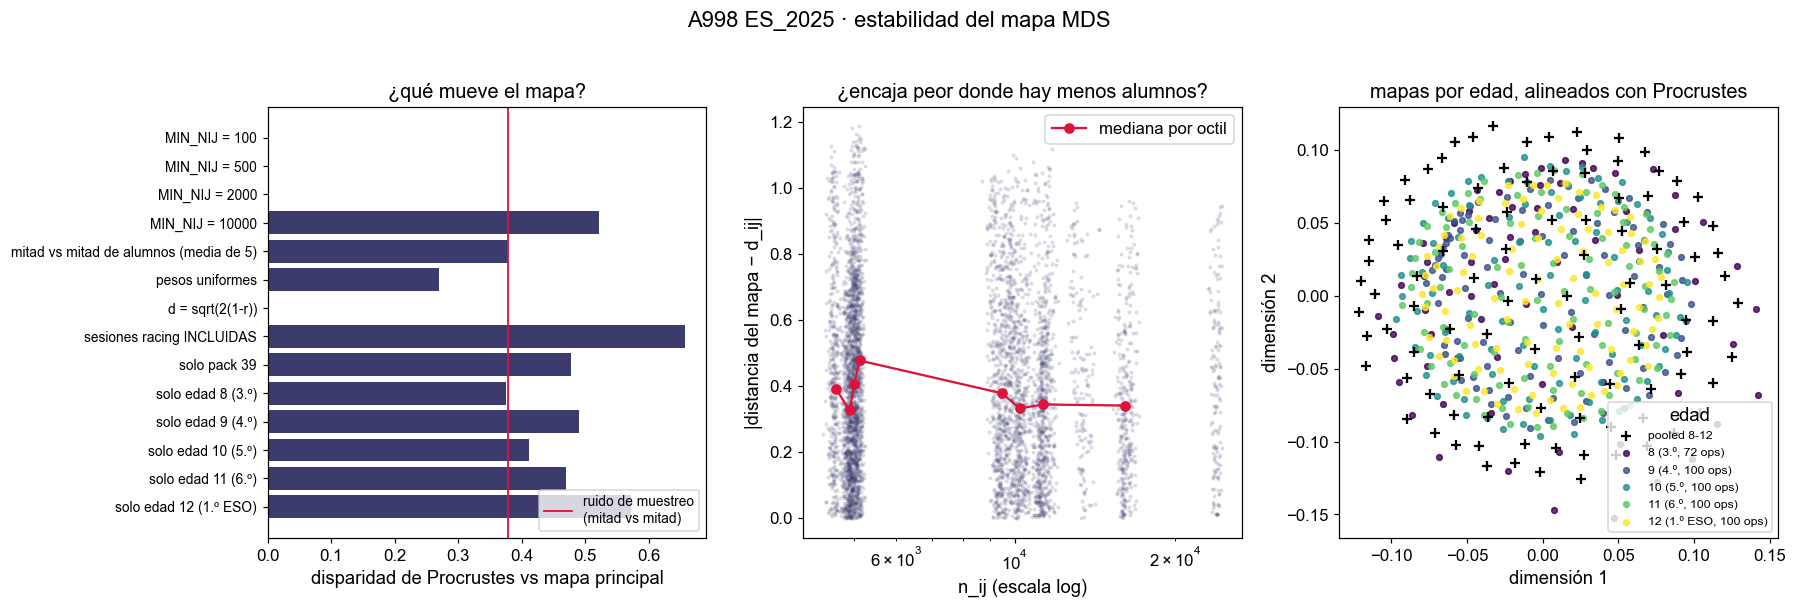

In [17]:
# =============================================================================
# 4. Estabilidad: ¿de qué depende el mapa?
# =============================================================================
# Un mapa de MDS siempre sale. La pregunta es si sale el MISMO cuando se cambia
# algo que no debería importar. Se comparan configuraciones con Procrustes
# (centrar, escalar, rotar y reflejar libremente, y medir lo que queda): la
# disparidad va de 0 (idénticos salvo rotación) a 1 (nada que ver), y es la misma
# medida que scipy.spatial.procrustes.
#
# Se prueban seis cosas, en este orden de importancia para este análisis:
#   1. n_ij: subir MIN_NIJ, es decir quedarse solo con las correlaciones bien
#      estimadas. Si el mapa aguanta, no lo están dibujando los pares flojos.
#   2. Mitades aleatorias de alumnos: el ruido de muestreo puro. ES LA UNIDAD DE
#      MEDIDA de todas las demás filas -- una variante con una disparidad de ese
#      orden no ha cambiado el mapa, solo lo ha vuelto a dibujar.
#   3. Pesos n_ij vs uniformes, y la otra forma de la distancia.
#   4. Sesiones racing dentro (la contaminación que el filtro quita).
#   5. Solo pack 39: exposición homogénea, ahí los huecos no los decide la edad.
#   6. Un mapa por edad, para ver si la estructura es la misma a los 8 y a los 12.
# Y además: ¿los pares con poco n_ij son los que peor encajan? (residuo vs n_ij).
#
# DOS TRAMPAS QUE ESTA CELDA EVITA A PROPÓSITO:
#   - Una submuestra tiene menos alumnos, así que sus n_ij son menores por
#     construcción. Aplicarle el MIN_NIJ del mapa completo mediría el tamaño de la
#     submuestra y no la estabilidad: el umbral se escala por la proporción de
#     alumnos (`scaled_min_nij`) y se imprime el que se ha usado en cada fila.
#   - Si en una variante alguna operación se queda sin ningún par con peso, el MDS
#     la deja en el origen y eso hincha la disparidad de esa fila. Esas
#     operaciones se excluyen de la comparación (la columna `ops` dice cuántas
#     quedan), en lugar de contarlas como "el mapa ha cambiado".

def procrustes_disparity(A, B):
    """Igual que scipy.spatial.procrustes: normaliza las dos configuraciones y
    ajusta rotación + escala óptimas. Devuelve (disparidad, A normalizada,
    B alineada sobre A), así que las dos salidas se pueden pintar en los mismos ejes."""
    A = np.asarray(A, float) - np.asarray(A, float).mean(0)
    B = np.asarray(B, float) - np.asarray(B, float).mean(0)
    A = A / np.linalg.norm(A)
    B = B / np.linalg.norm(B)
    U, s, Vt = np.linalg.svd(B.T @ A)
    Bt = (B @ (U @ Vt)) * s.sum()
    return float(((A - Bt) ** 2).sum()), A, Bt


try:                                    # verificación contra scipy si está
    from scipy.spatial import procrustes as sp_procrustes
    _A = np.random.default_rng(1).normal(size=(nf, 2))
    _B = _A @ np.array([[0.6, -0.8], [0.8, 0.6]]) * 2.5 + 3
    _B += np.random.default_rng(2).normal(scale=0.1, size=_B.shape)
    _d_sp = sp_procrustes(_A, _B)[2]
    _d_mine = procrustes_disparity(_A, _B)[0]
    print(f"verificación Procrustes: propio {_d_mine:.6f} vs scipy {_d_sp:.6f}")
    assert abs(_d_mine - _d_sp) < 1e-10
except ImportError:
    print("scipy no instalado: se salta la comprobación cruzada de Procrustes")


def scaled_min_nij(n_students_variant, n_students_main=None, floor=50):
    """MIN_NIJ reescalado a una submuestra: mismo nivel de fiabilidad relativa."""
    n_main = X_all.shape[0] if n_students_main is None else n_students_main
    return max(floor, int(round(MIN_NIJ * n_students_variant / max(n_main, 1))))


def usable_facts(Wm):
    """Índices con al menos un par con peso, quitando en cascada los que se quedan
    aislados al quitar otros."""
    good = np.ones(Wm.shape[0], dtype=bool)
    while True:
        iso = Wm[np.ix_(good, good)].sum(axis=1) == 0
        if not iso.any():
            return good
        good[np.where(good)[0][iso]] = False


def fit_map(Rm, Nm, form=DIST_FORM, min_nij=MIN_NIJ, mode=WEIGHTS, k=N_COMPONENTS,
            n_init=6, seed=SEED):
    Dm, Wm = prepare(Rm, Nm, form, min_nij, mode)
    Ym, _ = smacof_weighted(Dm, Wm, k, n_init=n_init, seed=seed,
                            init=classical_mds(Dm, n_components=k)[0])
    return Ym, stress_metrics(Dm, Wm, Ym)[0]


def fit_and_compare(name, Rm, Nm, ref=None, min_nij=MIN_NIJ, **kw):
    """Ajusta una variante y la compara con el mapa de referencia sobre las
    operaciones que la variante puede colocar de verdad."""
    mode = kw.get("mode", WEIGHTS)
    good = usable_facts(weights_from_n(Nm, min_nij, mode))
    sub = np.ix_(good, good)
    Ym, mm = fit_map(Rm[sub], Nm[sub], min_nij=min_nij, **kw)
    ref = Y if ref is None else ref
    d = procrustes_disparity(ref[good], Ym)[0]
    return {"variante": name, "disparidad": d, "stress1": mm["stress1_kruskal"],
            "ops": int(good.sum()), "min_nij": min_nij,
            "pares_con_peso": int((weights_from_n(Nm[sub], min_nij, mode) > 0).sum() / 2)}


rows = []

# 1. umbral de n_ij (absoluto: es justo lo que se está variando)
for thr in (100, 500, 2000, 10000, 25000):
    if not (N[off] >= thr).any():
        print(f"MIN_NIJ = {thr}: ningún par lo supera, se salta")
        continue
    rows.append(fit_and_compare(f"MIN_NIJ = {thr}", R, N, min_nij=thr))

# 2. mitades aleatorias de alumnos (5 repeticiones)
half_disp, half_ops = [], []
rng_split = np.random.default_rng(SEED)
for rep in range(5):
    perm = rng_split.permutation(X_all.shape[0])
    ia, ib = perm[: len(perm) // 2], perm[len(perm) // 2:]
    thr_half = scaled_min_nij(len(ia))
    Ra, Na = phi_pairwise(X_all[ia][:, KEEP])
    Rb, Nb = phi_pairwise(X_all[ib][:, KEEP])
    good = usable_facts(weights_from_n(Na, thr_half)) & usable_facts(weights_from_n(Nb, thr_half))
    sub = np.ix_(good, good)
    Ya, _ = fit_map(Ra[sub], Na[sub], min_nij=thr_half, n_init=4, seed=SEED + rep)
    Yb, _ = fit_map(Rb[sub], Nb[sub], min_nij=thr_half, n_init=4, seed=SEED + 100 + rep)
    half_disp.append(procrustes_disparity(Ya, Yb)[0])
    half_ops.append(int(good.sum()))
HALF = float(np.mean(half_disp))
rows.append({"variante": "mitad vs mitad de alumnos (media de 5)", "disparidad": HALF,
             "stress1": np.nan, "ops": int(np.mean(half_ops)),
             "min_nij": scaled_min_nij(X_all.shape[0] // 2), "pares_con_peso": np.nan})
print(f"\nmitades: disparidad {HALF:.4f} (mín {min(half_disp):.4f}, máx {max(half_disp):.4f}) "
      f"con MIN_NIJ reescalado a {scaled_min_nij(X_all.shape[0] // 2)} y "
      f"{int(np.mean(half_ops))} operaciones")

# 3. pesos uniformes y la otra distancia
rows.append(fit_and_compare("pesos uniformes", R, N, mode="uniform"))
rows.append(fit_and_compare("d = sqrt(2(1-r))", R, N, form="sqrt(2(1-r))"))

# 4. sin filtrar las sesiones racing
if RUN_RACING_CHECK:
    att_raw = load_last_attempts(exclude_racing=False)
    Xr, _, _ = build_matrix(att_raw, AGES_POOL)
    Rr, Nr = phi_pairwise(Xr[:, KEEP])
    rows.append(fit_and_compare("sesiones racing INCLUIDAS", Rr, Nr))
    print(f"\nracing incluido: {Xr.shape[0]:,}".replace(",", ".") +
          f" alumnos (vs {X_all.shape[0]:,}".replace(",", ".") + " filtrados) · "
          f"r mediana entre pares {np.nanmedian(Rr[off]):+.3f} vs "
          f"{np.nanmedian(R[off]):+.3f} filtrado")
    print("  (si la r mediana sube al incluirlos es exactamente el artefacto que el "
          "filtro evita: una fila de ceros correlaciona todo con todo)")

# 5. solo pack 39 (todas las tablas 0-9 en el mismo pack -> exposición homogénea)
if RUN_PACK39_CHECK:
    att_39 = load_last_attempts(exclude_racing=EXCLUDE_RACING, pack=39)
    X39, _, _ = build_matrix(att_39, AGES_POOL)
    R39, N39 = phi_pairwise(X39[:, KEEP])
    thr39 = scaled_min_nij(X39.shape[0])
    rows.append(fit_and_compare("solo pack 39", R39, N39, min_nij=thr39))
    print(f"\npack 39: {X39.shape[0]:,}".replace(",", ".") + " alumnos · "
          f"celdas observadas {100 * np.mean(~np.isnan(X39)):.1f}% "
          f"(vs {100 * np.mean(~np.isnan(X_all)):.1f}% con todos los packs) · "
          f"n_ij mediano {np.median(N39[off]):,.0f}".replace(",", ".") +
          f" · MIN_NIJ reescalado a {thr39}")

# 6. un mapa por edad
Y_age, age_rows, Y_main_norm = {}, [], None
for age in AGES_POOL:
    Xa, _, _ = build_matrix(att, [age])
    Ra, Na = phi_pairwise(Xa[:, KEEP])
    thr_a = scaled_min_nij(Xa.shape[0])
    good_a = usable_facts(weights_from_n(Na, thr_a))
    sub = np.ix_(good_a, good_a)
    Ya, ma = fit_map(Ra[sub], Na[sub], min_nij=thr_a, n_init=4)
    d, A_norm, Ya_al = procrustes_disparity(Y[good_a], Ya)
    Y_age[age] = (Ya_al, good_a)
    if Y_main_norm is None or good_a.sum() > len(Y_main_norm):
        Y_main_norm = A_norm
    age_rows.append((age, Xa.shape[0], np.median(Na[off]), thr_a, int(good_a.sum()),
                     ma["stress1_kruskal"], d))
    rows.append({"variante": f"solo edad {age} ({AGE_GRADE.get(age, '')})",
                 "disparidad": d, "stress1": ma["stress1_kruskal"],
                 "ops": int(good_a.sum()), "min_nij": thr_a,
                 "pares_con_peso": int((weights_from_n(Na[sub], thr_a) > 0).sum() / 2)})

stab = pd.DataFrame(rows)
print("\n--- estabilidad (disparidad de Procrustes: 0 = mismo mapa; "
      f"ruido de muestreo = {HALF:.4f}) ---")
print(stab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n--- por edad ---")
print(pd.DataFrame(age_rows, columns=["edad", "alumnos", "n_ij_mediano", "min_nij",
                                      "ops", "stress1", "disparidad_vs_pooled"])
        .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# --- residuo vs n_ij: ¿el mapa falla donde hay poca información? --------------
res = np.abs(dist_fit - D)
sel_all = np.triu(np.ones_like(D, dtype=bool), 1) & (W > 0)
nn, rr = N[sel_all], res[sel_all]
qs = np.unique(np.quantile(nn, np.linspace(0, 1, 9)))
bins = np.digitize(nn, qs[1:-1])
med_res = [np.median(rr[bins == b]) for b in range(len(qs) - 1)]
med_n = [np.median(nn[bins == b]) for b in range(len(qs) - 1)]
print(f"\ncorrelación de Spearman entre n_ij y |residuo|: "
      f"{pd.Series(nn).corr(pd.Series(rr), method='spearman'):+.3f} "
      "(negativa = los pares con más alumnos encajan mejor, que es lo esperable; "
      "nula o positiva querría decir que el desajuste no es cuestión de muestra)")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4))

ax = axes[0]
lab = stab["variante"].to_list()
ax.barh(range(len(lab)), stab["disparidad"], color="#3b3b6d")
ax.axvline(HALF, color="crimson", lw=1.2, label="ruido de muestreo\n(mitad vs mitad)")
ax.set_yticks(range(len(lab)))
ax.set_yticklabels(lab, fontsize=FONT_BASE - 3)
ax.invert_yaxis()
ax.set_xlabel("disparidad de Procrustes vs mapa principal")
ax.set_title("¿qué mueve el mapa?")
ax.legend(loc="lower right", fontsize=FONT_BASE - 3)

ax = axes[1]
ax.scatter(nn, rr, s=3, alpha=0.12, color="#3b3b6d")
ax.plot(med_n, med_res, color="crimson", marker="o", lw=1.5, label="mediana por octil")
ax.set_xscale("log")
ax.set_xlabel("n_ij (escala log)"); ax.set_ylabel("|distancia del mapa − d_ij|")
ax.set_title("¿encaja peor donde hay menos alumnos?")
ax.legend()

ax = axes[2]
cmap = plt.get_cmap("viridis")
ax.scatter(Y_main_norm[:, 0], Y_main_norm[:, 1], s=46, marker="+", color="black",
           label="pooled 8-12", zorder=3)
for k, age in enumerate(AGES_POOL):
    Ya_al, good_a = Y_age[age]
    ax.scatter(Ya_al[:, 0], Ya_al[:, 1], s=14, alpha=0.8,
               color=cmap(k / max(len(AGES_POOL) - 1, 1)),
               label=f"{age} ({AGE_GRADE.get(age, '')}, {int(good_a.sum())} ops)")
ax.set_title("mapas por edad, alineados con Procrustes")
ax.set_xlabel("dimensión 1"); ax.set_ylabel("dimensión 2")
ax.legend(title="edad", fontsize=FONT_BASE - 4)

fig.suptitle("A998 ES_2025 · estabilidad del mapa MDS", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_estabilidad.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_estabilidad.pdf")
plt.show()

verificación normal: max |ppf - tabla| = 4.60e-10 · max |cdf(tabla) - p| = 1.02e-10
verificación tetracórica: r real +0.60 -> recuperada +0.602 (phi sobre los mismos datos: +0.321, tasas base 30%/70%)
verificación tetracórica: r real -0.35 -> recuperada -0.350 (phi sobre los mismos datos: -0.227, tasas base 50%/50%)
verificación tetracórica: r real +0.00 -> recuperada +0.004 (phi sobre los mismos datos: +0.002, tasas base 20%/80%)

pares en el borde (|r| ~ 1, alguna celda de la 2x2 vacía): 0 de 4950
phi vs tetracórica: r = 0.943 · phi mediana +0.203 · tetracórica mediana +0.429
mapa tetracórico: 100 operaciones · stress-1 0.4064 · disparidad de Procrustes vs mapa phi 0.1710 (ruido de muestreo, mitad vs mitad: 0.3780)


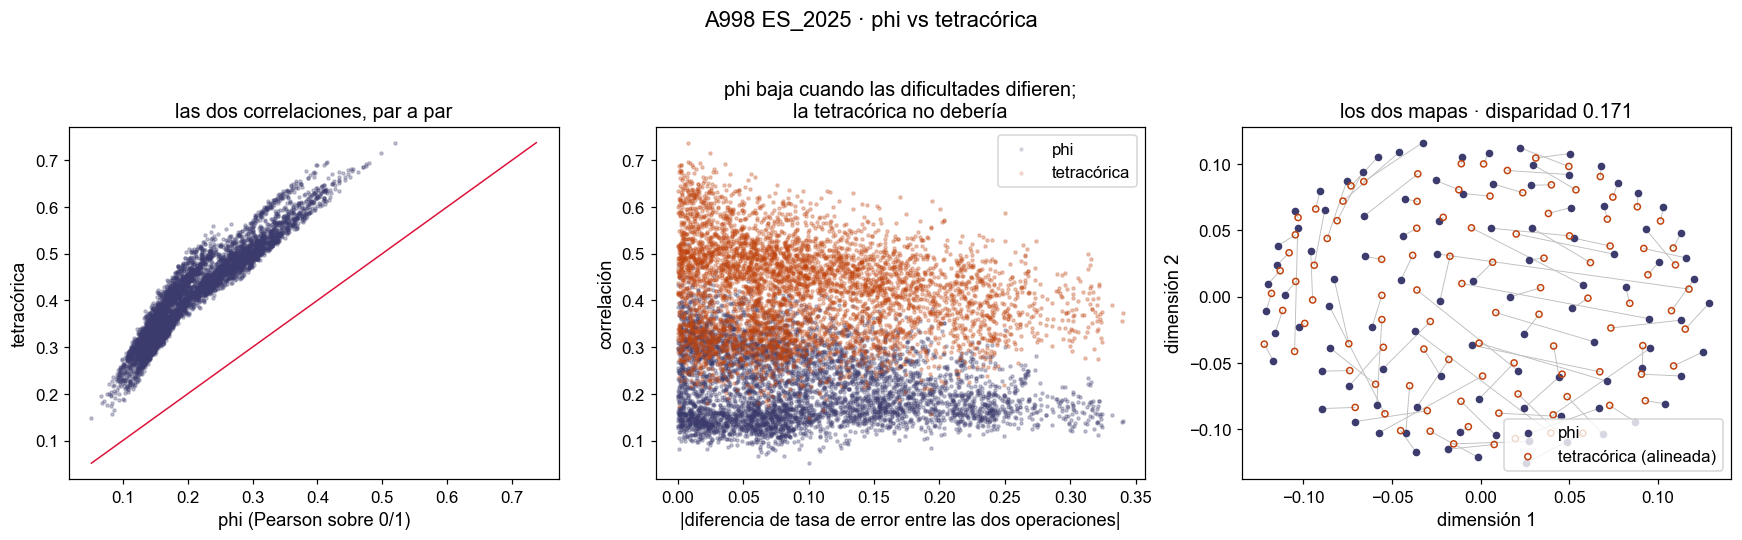

In [18]:
# =============================================================================
# 5. Robustez: lo mismo con correlación tetracórica
# =============================================================================
# POR QUÉ. phi (= Pearson sobre 0/1) está limitada por las tasas base: dos
# operaciones con dificultades muy distintas no pueden correlacionar alto ni
# aunque dependan de lo mismo. Es decir, parte de la geometría del mapa de la
# celda 3 es dificultad, justo la variable que solo querías usar para colorear.
# La tetracórica supone que detrás de cada 0/1 hay una variable continua normal
# con un umbral, y estima la correlación de esas variables latentes: la
# dificultad se va al umbral y no al coeficiente.
#
# Es un supuesto, no una verdad -- por eso es una comprobación de robustez y no
# el mapa principal. Si los dos mapas coinciden salvo rotación, la lectura del
# mapa principal no depende de ese supuesto ni de la dificultad.
#
# CÓMO. De cada par se tiene la tabla 2x2 sobre sus casos completos
# (n11, n10, n01, n00), y se busca la r que reproduce n11/n con marginales fijas:
#     P(X>h, Y>k; r) = p_i·p_j + integral_0^r phi2(h, k, t) dt
# La integral se evalúa con Gauss-Legendre y la r se busca por bisección, todo
# vectorizado sobre los ~5.000 pares a la vez (segundos, no minutos). Sin scipy:
# solo hace falta erf.

from math import erf, sqrt as _sqrt


def _norm_cdf(x):
    x = np.asarray(x, dtype=float)
    flat = x.ravel()
    out = np.array([0.5 * (1.0 + erf(v / _sqrt(2.0))) if np.isfinite(v)
                    else (1.0 if v > 0 else 0.0) for v in flat])
    return out.reshape(x.shape)


def _norm_ppf(p, lo=-8.5, hi=8.5, iters=200):
    """Inversa de la normal por bisección vectorizada (basta y sobra: se usa una
    vez por par, no dentro de ningún bucle de optimización)."""
    p = np.asarray(p, dtype=float)
    a = np.full(p.shape, lo, dtype=float)
    b = np.full(p.shape, hi, dtype=float)
    for _ in range(iters):
        m = 0.5 * (a + b)
        go_up = _norm_cdf(m) < p          # Phi(m) por debajo: hay que subir
        a = np.where(go_up, m, a)
        b = np.where(go_up, b, m)
    out = 0.5 * (a + b)
    return np.where((p <= 0) | (p >= 1), np.nan, out)


# Comprobación de los dos ladrillos ANTES de usarlos, y contra valores conocidos
# de tabla, no contra sí mismos: la primera versión de _norm_ppf tenía las dos
# ramas de la bisección mal y devolvía 0 para todo. La verificación por simulación
# de más abajo NO lo detectaba, porque usaba la misma función para poner el umbral
# de los datos simulados y para estimarlo, así que el error se cancelaba. Regla
# general: un helper no se verifica con el helper.
_KNOWN = {0.975: 1.959963985, 0.95: 1.644853627, 0.75: 0.674489750,
          0.5: 0.0, 0.30: -0.524400513, 0.025: -1.959963985}
_p = np.array(list(_KNOWN))
_want = np.array(list(_KNOWN.values()))
_got_ppf = _norm_ppf(_p)
_got_cdf = _norm_cdf(_want)
print(f"verificación normal: max |ppf - tabla| = {np.abs(_got_ppf - _want).max():.2e} · "
      f"max |cdf(tabla) - p| = {np.abs(_got_cdf - _p).max():.2e}")
assert np.abs(_got_ppf - _want).max() < 1e-8 and np.abs(_got_cdf - _p).max() < 1e-9


_GL_X, _GL_W = np.polynomial.legendre.leggauss(48)


def _bvn_upper(h, k, r):
    """P(Z1 > h, Z2 > k; r) por la identidad de Sheppard/Plackett:
    Phi2(h,k;r) = Phi(h)Phi(k) + integral_0^r phi2(h,k,t) dt."""
    h = h[..., None]
    k = k[..., None]
    t = r[..., None] * 0.5 * (_GL_X + 1.0)          # nodos en [0, r] (r puede ser < 0)
    w = r[..., None] * 0.5 * _GL_W
    one_m = 1.0 - t ** 2
    dens = np.exp(-(h ** 2 - 2.0 * t * h * k + k ** 2) / (2.0 * one_m)) / \
        (2.0 * np.pi * np.sqrt(one_m))
    integral = (w * dens).sum(-1)
    Ph, Pk = _norm_cdf(h[..., 0]), _norm_cdf(k[..., 0])
    phi2 = Ph * Pk + integral
    return 1.0 - Ph - Pk + phi2


def tetrachoric(n11, n10, n01, n00, iters=64, rmax=0.9999):
    """Correlación tetracórica de cada par, vectorizada. Devuelve (R, boundary)."""
    n = n11 + n10 + n01 + n00
    with np.errstate(invalid="ignore", divide="ignore"):
        pi = (n11 + n10) / n
        pj = (n11 + n01) / n
        p11 = n11 / n
    h = _norm_ppf(1.0 - pi)
    k = _norm_ppf(1.0 - pj)
    ok = np.isfinite(h) & np.isfinite(k) & (n >= 3)

    hh = np.where(ok, h, 0.0)
    kk = np.where(ok, k, 0.0)
    target = np.where(ok, p11, 0.0)

    lo = np.full(n.shape, -rmax)
    hi = np.full(n.shape, rmax)
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        val = _bvn_upper(hh, kk, mid)
        too_low = val < target
        lo = np.where(too_low, mid, lo)
        hi = np.where(too_low, hi, mid)
    R_t = 0.5 * (lo + hi)
    boundary = ok & (np.abs(R_t) > rmax - 1e-3)
    R_t = np.where(ok, R_t, np.nan)
    np.fill_diagonal(R_t, 1.0)
    return R_t, boundary


# --- verificación: recuperar una r conocida de datos simulados -----------------
_rng = np.random.default_rng(7)
for r_true, cut_i, cut_j in ((0.60, 0.30, 0.70), (-0.35, 0.50, 0.50), (0.0, 0.20, 0.80)):
    z = _rng.multivariate_normal([0, 0], [[1, r_true], [r_true, 1]], size=400_000)
    xi = (z[:, 0] > _norm_ppf(np.array(1 - cut_i))).astype(float)
    xj = (z[:, 1] > _norm_ppf(np.array(1 - cut_j))).astype(float)
    # tablas 2x2 replicadas en una matriz 2x2 y se lee la casilla FUERA de la
    # diagonal: `tetrachoric` pone 1 en la diagonal (es una matriz de
    # correlaciones), así que leer [0,0] devolvería siempre 1 y la verificación
    # no verificaría nada.
    a11 = np.full((2, 2), float(np.sum((xi == 1) & (xj == 1))))
    a10 = np.full((2, 2), float(np.sum((xi == 1) & (xj == 0))))
    a01 = np.full((2, 2), float(np.sum((xi == 0) & (xj == 1))))
    a00 = np.full((2, 2), float(np.sum((xi == 0) & (xj == 0))))
    got = tetrachoric(a11, a10, a01, a00)[0][0, 1]
    phi_here = np.corrcoef(xi, xj)[0, 1]
    print(f"verificación tetracórica: r real {r_true:+.2f} -> recuperada "
          f"{got:+.3f} (phi sobre los mismos datos: {phi_here:+.3f}, "
          f"tasas base {cut_i:.0%}/{cut_j:.0%})")
    assert abs(got - r_true) < 0.02, "la tetracórica no recupera la r simulada"

# --- tetracórica sobre los datos reales ---------------------------------------
c11, c10, c01, c00, cN = cell_counts(X_all[:, KEEP])
R_tet, at_bound = tetrachoric(c11, c10, c01, c00)
print(f"\npares en el borde (|r| ~ 1, alguna celda de la 2x2 vacía): "
      f"{int(at_bound[off].sum() / 2)} de {nf * (nf - 1) // 2}")
m = off & np.isfinite(R) & np.isfinite(R_tet) & (N >= MIN_NIJ)
print(f"phi vs tetracórica: r = {np.corrcoef(R[m], R_tet[m])[0, 1]:.3f} · "
      f"phi mediana {np.median(R[m]):+.3f} · tetracórica mediana {np.median(R_tet[m]):+.3f}")

good_t = usable_facts(weights_from_n(N, MIN_NIJ))
sub_t = np.ix_(good_t, good_t)
Y_tet, m_tet = fit_map(R_tet[sub_t], N[sub_t])
d_tet, Y_phi_norm, Y_tet_al = procrustes_disparity(Y[good_t], Y_tet)
print(f"mapa tetracórico: {int(good_t.sum())} operaciones · "
      f"stress-1 {m_tet['stress1_kruskal']:.4f} · "
      f"disparidad de Procrustes vs mapa phi {d_tet:.4f} "
      f"(ruido de muestreo, mitad vs mitad: {HALF:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].scatter(R[m], R_tet[m], s=4, alpha=0.15, color="#3b3b6d")
lims = [min(R[m].min(), R_tet[m].min()), max(R[m].max(), R_tet[m].max())]
axes[0].plot(lims, lims, color="crimson", lw=1)
axes[0].set_xlabel("phi (Pearson sobre 0/1)"); axes[0].set_ylabel("tetracórica")
axes[0].set_title("las dos correlaciones, par a par")

err_map = fact_stats.set_index(["factor_1", "factor_2"])["err_ageavg"].to_dict()
err_vec = np.array([err_map.get(f, np.nan) for f in facts])
diff_err = np.abs(err_vec[:, None] - err_vec[None, :])
sel2 = m & np.isfinite(diff_err)
axes[1].scatter(diff_err[sel2], R[sel2], s=4, alpha=0.15, color="#3b3b6d", label="phi")
axes[1].scatter(diff_err[sel2], R_tet[sel2], s=4, alpha=0.15, color="#c1440e",
                label="tetracórica")
axes[1].set_xlabel("|diferencia de tasa de error entre las dos operaciones|")
axes[1].set_ylabel("correlación")
axes[1].set_title("phi baja cuando las dificultades difieren;\nla tetracórica no debería")
axes[1].legend()

for p0, p1 in zip(Y_phi_norm, Y_tet_al):     # une cada operación con su gemela
    axes[2].plot([p0[0], p1[0]], [p0[1], p1[1]], color="0.75", lw=0.6, zorder=1)
axes[2].scatter(Y_phi_norm[:, 0], Y_phi_norm[:, 1], s=16, color="#3b3b6d",
                label="phi", zorder=2)
axes[2].scatter(Y_tet_al[:, 0], Y_tet_al[:, 1], s=16, facecolors="none",
                edgecolors="#c1440e", label="tetracórica (alineada)", zorder=2)
axes[2].set_title(f"los dos mapas · disparidad {d_tet:.3f}")
axes[2].set_xlabel("dimensión 1"); axes[2].set_ylabel("dimensión 2")
axes[2].legend()

fig.suptitle("A998 ES_2025 · phi vs tetracórica", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_tetracorica.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_tetracorica.pdf")
plt.show()

¿cuánta de cada variable reproduce el mapa? (ajuste sobre las 2 coordenadas)
                      variable    R2  dirección_grados  n_ops
tasa de error (media por edad) 0.733            84.712    100
      TR mediano, aciertos (s) 0.642            65.095    100
               primer operando 0.286            61.317    100
              segundo operando 0.242            81.322    100
                      producto 0.492            75.558    100
                max(operandos) 0.304            71.058    100

los 3 vecinos más cercanos de algunas operaciones en el mapa:
    6×8 -> 8×6, 4×7, 7×8
    7×8 -> 8×6, 8×8, 6×8
    2×3 -> 1×9, 0×9, 5×3
    5×5 -> 5×3, 7×3, 3×5
    0×7 -> 0×2, 0×6, 0×8
    1×4 -> 1×6, 1×7, 2×9
    9×9 -> 0×3, 6×3, 9×3


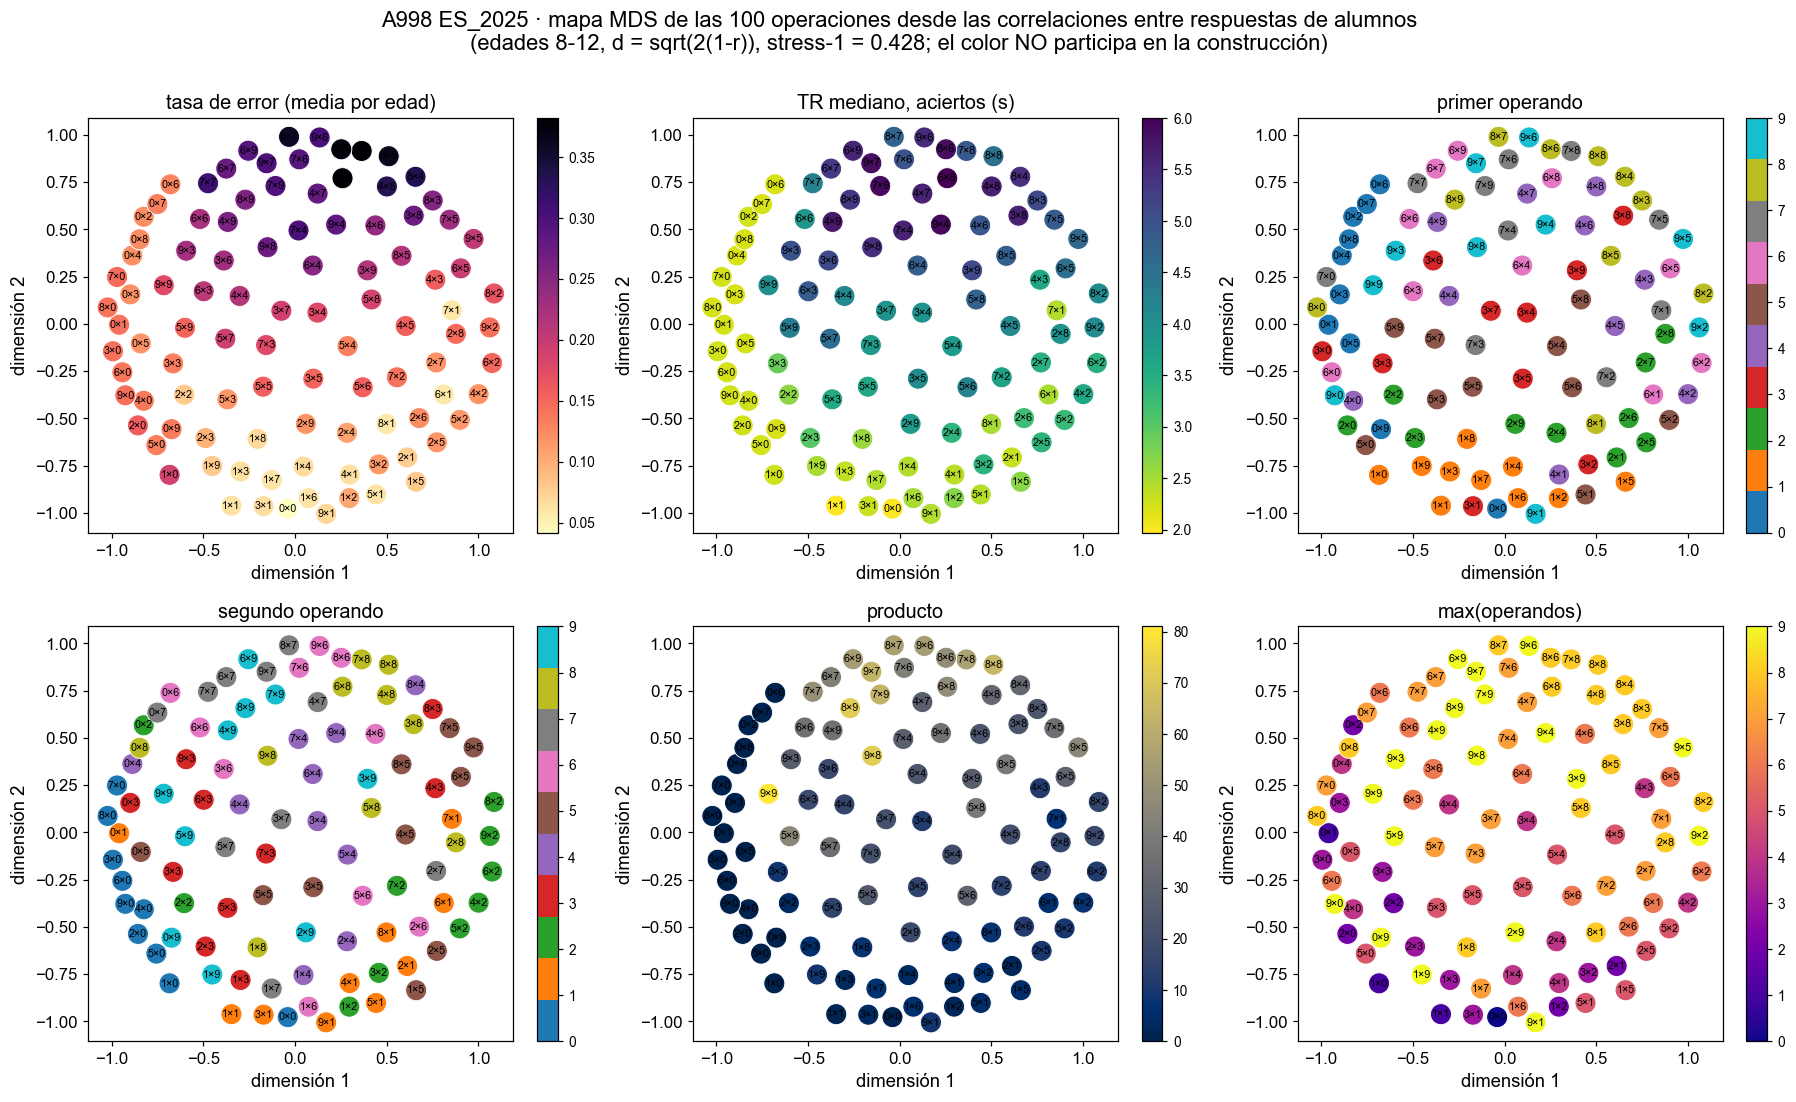

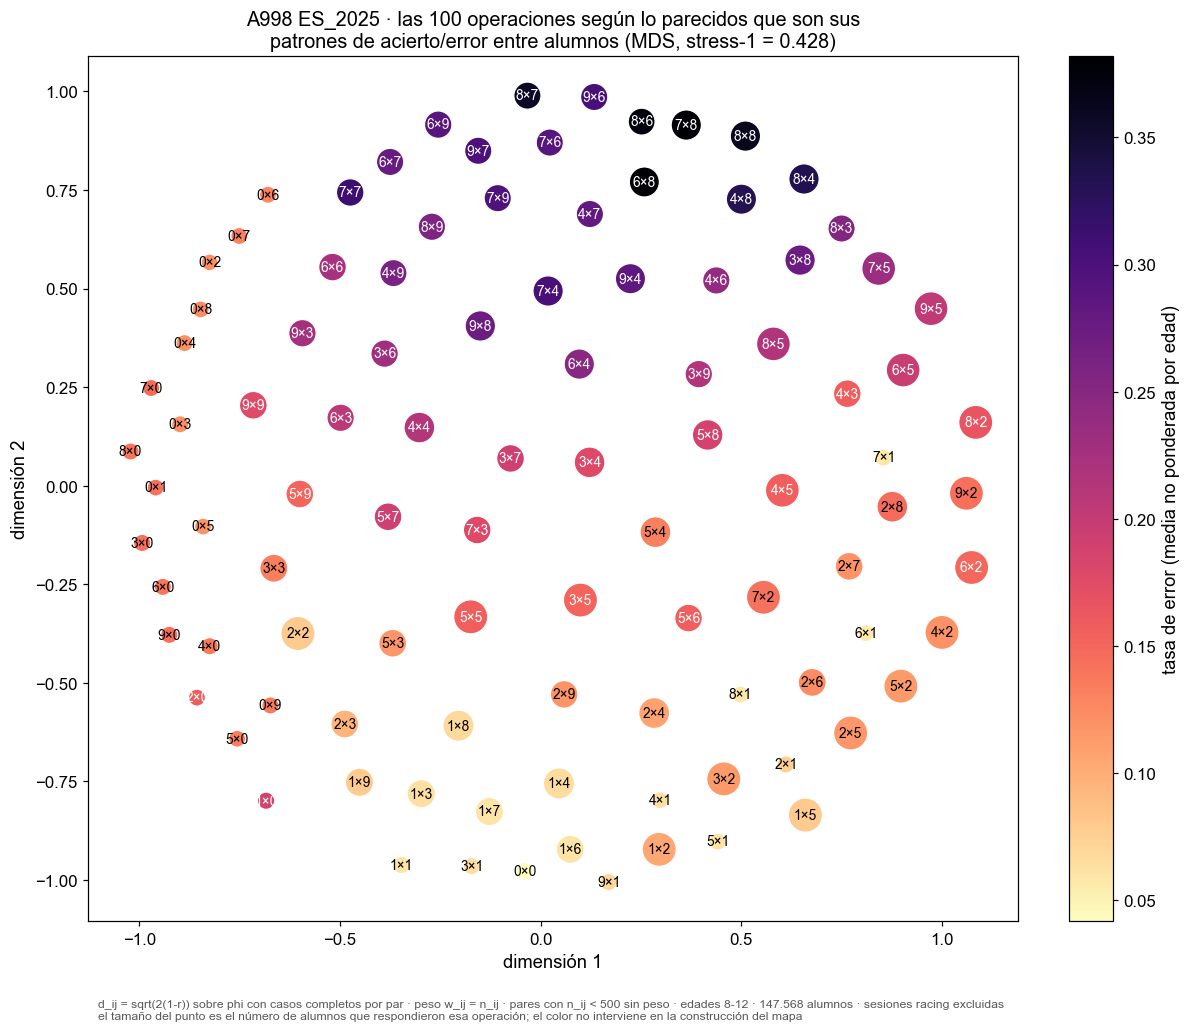


cruce con a998_fact_heatmap_by_age.sql (100 operaciones): Spearman 0.884 · Pearson 0.901
  nivel: última respuesta sin racing 17.4% vs todos los intentos sin filtrar 30.0%


In [19]:
# =============================================================================
# 6. El mapa: las 100 operaciones, coloreadas por variables que NO lo construyen
# =============================================================================
# El mapa sale solo de la matriz de correlaciones. Tasa de error, TR, operandos y
# tamaño del producto se pintan encima. Que el mapa las ordene es el resultado;
# si no las ordenara, también lo sería.
#
# ORIENTACIÓN. Un mapa de MDS está definido salvo rotación, reflexión y traslación
# (las distancias no cambian). Para que el mismo mapa salga igual cada vez que se
# ejecuta esto, se rota a sus ejes principales (PCA) y se fija el signo con una
# regla explícita sobre el tamaño del producto. Es una rotación, nada más: no
# mueve ninguna distancia y no usa las variables de color para colocar los puntos.
#
# CUÁNTO EXPLICA CADA VARIABLE. Como los ejes son arbitrarios, no vale mirar la
# correlación con "la dimensión 1": se ajusta cada variable sobre las DOS
# coordenadas (R^2 de un plano) y se da la dirección del gradiente en grados. Eso
# sí es invariante a la rotación.

def orient(Ym, product_vec):
    Ym = np.asarray(Ym, float) - np.asarray(Ym, float).mean(0)
    _, _, Vt = np.linalg.svd(Ym, full_matrices=False)
    Z = Ym @ Vt.T
    big = product_vec >= np.median(product_vec)
    if np.mean(Z[big, 0]) < np.mean(Z[~big, 0]):      # productos grandes a la derecha
        Z[:, 0] *= -1
    if np.mean(Z[big, 1]) < 0:                        # y arriba
        Z[:, 1] *= -1
    return Z


prod_vec = np.array([a * b for a, b in facts], dtype=float)
f1_vec = np.array([a for a, _ in facts], dtype=float)
f2_vec = np.array([b for _, b in facts], dtype=float)
rt_map = fact_stats.set_index(["factor_1", "factor_2"])["median_rt"].to_dict()
rt_vec = np.array([rt_map.get(f, np.nan) for f in facts])
Z = orient(Y, prod_vec)

COLOR_VARS = {
    "tasa de error (media por edad)": (err_vec, "magma_r", "{:.0%}"),
    "TR mediano, aciertos (s)": (rt_vec, "viridis_r", "{:.1f}"),
    "primer operando": (f1_vec, "tab10", "{:.0f}"),
    "segundo operando": (f2_vec, "tab10", "{:.0f}"),
    "producto": (prod_vec, "cividis", "{:.0f}"),
    "max(operandos)": (np.maximum(f1_vec, f2_vec), "plasma", "{:.0f}"),
}

# --- ¿cuánto de cada variable hay en el mapa? ---------------------------------
fit_rows = []
for name, (v, _, _) in COLOR_VARS.items():
    ok = np.isfinite(v)
    A = np.column_stack([np.ones(ok.sum()), Z[ok, 0], Z[ok, 1]])
    coef, *_ = np.linalg.lstsq(A, v[ok], rcond=None)
    pred = A @ coef
    ss_res = float(((v[ok] - pred) ** 2).sum())
    ss_tot = float(((v[ok] - v[ok].mean()) ** 2).sum())
    ang = np.degrees(np.arctan2(coef[2], coef[1])) % 180
    fit_rows.append((name, 1 - ss_res / ss_tot, ang, int(ok.sum())))
print("¿cuánta de cada variable reproduce el mapa? (ajuste sobre las 2 coordenadas)")
print(pd.DataFrame(fit_rows, columns=["variable", "R2", "dirección_grados", "n_ops"])
        .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# --- vecinos más próximos: la lectura fact a fact -----------------------------
Dmap = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
np.fill_diagonal(Dmap, np.inf)
print("\nlos 3 vecinos más cercanos de algunas operaciones en el mapa:")
for f in [(6, 8), (7, 8), (2, 3), (5, 5), (0, 7), (1, 4), (9, 9)]:
    if f in facts:
        i = facts.index(f)
        near = np.argsort(Dmap[i])[:3]
        print(f"  {FACT_LABEL[f]:>5} -> " + ", ".join(labels[j] for j in near))

# --- figura principal: seis coloreados del MISMO mapa -------------------------
fig, axes = plt.subplots(2, 3, figsize=(16.5, 10))
for ax, (name, (v, cmap_name, fmt)) in zip(axes.ravel(), COLOR_VARS.items()):
    ok = np.isfinite(v)
    sc = ax.scatter(Z[ok, 0], Z[ok, 1], c=v[ok], cmap=cmap_name, s=190,
                    edgecolors="white", linewidths=0.6)
    for i in np.where(ok)[0]:
        ax.annotate(labels[i], (Z[i, 0], Z[i, 1]), ha="center", va="center",
                    fontsize=FONT_BASE - 5, color="black")
    if (~ok).any():
        ax.scatter(Z[~ok, 0], Z[~ok, 1], c="0.85", s=190, edgecolors="white",
                   linewidths=0.6)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046)
    cb.ax.tick_params(labelsize=FONT_BASE - 3)
    ax.set_title(name)
    ax.set_xlabel("dimensión 1"); ax.set_ylabel("dimensión 2")
fig.suptitle(f"A998 ES_2025 · mapa MDS de las {nf} operaciones desde las correlaciones "
             f"entre respuestas de alumnos\n(edades {min(AGES_POOL)}-{max(AGES_POOL)}, "
             f"d = {DIST_FORM}, stress-1 = {met['stress1_kruskal']:.3f}; "
             "el color NO participa en la construcción)", y=1.0)
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_mapa_coloreado.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_mapa_coloreado.pdf")
plt.show()

# --- figura grande: un solo mapa, etiquetado, coloreado por tasa de error ------
fig, ax = plt.subplots(figsize=(11, 9.5))
ok = np.isfinite(err_vec)
sizes = 120 + 380 * (np.log10(np.maximum(n_stu_fact[KEEP], 1)) -
                     np.log10(np.maximum(n_stu_fact[KEEP], 1)).min()) / \
    max(np.ptp(np.log10(np.maximum(n_stu_fact[KEEP], 1))), 1e-9)
sc = ax.scatter(Z[:, 0], Z[:, 1], c=np.where(ok, err_vec, np.nan), cmap="magma_r",
                s=sizes, edgecolors="white", linewidths=0.8)
for i, lab_i in enumerate(labels):
    ax.annotate(lab_i, (Z[i, 0], Z[i, 1]), ha="center", va="center",
                fontsize=FONT_BASE - 3,
                color="white" if (ok[i] and err_vec[i] > np.nanmedian(err_vec)) else "black")
cb = fig.colorbar(sc, ax=ax, fraction=0.046)
cb.set_label("tasa de error (media no ponderada por edad)")
ax.set_xlabel("dimensión 1"); ax.set_ylabel("dimensión 2")
ax.set_title(f"A998 ES_2025 · las {nf} operaciones según lo parecidos que son sus\n"
             f"patrones de acierto/error entre alumnos (MDS, stress-1 = "
             f"{met['stress1_kruskal']:.3f})")
ax.text(0.01, -0.09,
        f"d_ij = {DIST_FORM} sobre phi con casos completos por par · peso w_ij = "
        f"{'n_ij' if WEIGHTS == 'nij' else 'uniforme'} · pares con n_ij < {MIN_NIJ} "
        f"sin peso · edades {min(AGES_POOL)}-{max(AGES_POOL)} · "
        f"{X_all.shape[0]:,}".replace(",", ".") + " alumnos · sesiones racing excluidas"
        "\nel tamaño del punto es el número de alumnos que respondieron esa operación; "
        "el color no interviene en la construcción del mapa",
        transform=ax.transAxes, fontsize=FONT_BASE - 4, va="top", color="0.35")
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_mapa.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_mapa.pdf")
plt.show()

# --- contraste con la query de dificultad ya existente ------------------------
# Cruce sano: la tasa de error de este notebook sale de la ÚLTIMA respuesta de
# cada alumno y sin sesiones racing; a998_fact_heatmap_by_age.sql la calcula sobre
# TODOS los intentos y sin filtrar. Si el orden de dificultad coincide, la regla
# de agregación no está deformando la variable con la que se colorea.
if RUN_HEATMAP_CROSSCHECK:
    hm = cached_query(HERE / "queries" / "a998_fact_heatmap_by_age.sql", CACHE_DIR)
    hm = hm[hm["classroom_course_age"].isin(AGES_POOL)]
    hm_err = (hm.groupby(["factor_1", "factor_2"])["error_rate"].mean()
                .rename("err_heatmap").reset_index())
    cmp = fact_stats.merge(hm_err, on=["factor_1", "factor_2"], how="inner")
    print(f"\ncruce con a998_fact_heatmap_by_age.sql ({len(cmp)} operaciones): "
          f"Spearman {cmp[['err_ageavg', 'err_heatmap']].corr(method='spearman').iloc[0, 1]:.3f} · "
          f"Pearson {cmp[['err_ageavg', 'err_heatmap']].corr().iloc[0, 1]:.3f}")
    print(f"  nivel: última respuesta sin racing {cmp['err_ageavg'].mean():.1%} vs "
          f"todos los intentos sin filtrar {cmp['err_heatmap'].mean():.1%}")

## Cómo leer este mapa (y cómo no)

**Qué es.** Cada punto es una operación. La cercanía significa **una sola cosa**: los alumnos que aciertan una tienden a acertar la otra (y los que fallan una, fallan la otra). No significa que se parezcan visualmente, ni que se enseñen juntas, ni que tengan dificultad parecida — aunque cualquiera de esas cosas puede ser la *causa* de que sus patrones coincidan, y para eso están los colores.

**Cómo se ha construido.** Última respuesta de cada alumno a cada operación, `X = 1` acierto / `X = 0` error, huecos donde el alumno no vio la operación. `r_ij` = phi (Pearson sobre 0/1) con los alumnos que respondieron **ambas** operaciones, guardando `n_ij`; `d_ij = 2(1 − r_ij)`; SMACOF ponderado por `n_ij`, con peso 0 en los pares con `n_ij < MIN_NIJ`. Ninguna variable de color entra en el cálculo.

**Las cuatro cosas que hay que mirar antes de creerse una lectura del mapa:**

1. **`stress`** (celda 3). Es el error de aplanar la matriz a dos dimensiones. Con la curva de `stress` por dimensiones al lado: si baja mucho al pasar a 3D, hay estructura que el plano no puede mostrar y dos puntos cercanos en el plano pueden estar lejos de verdad.
2. **`n_ij`** (celdas 2 y 4). Las correlaciones no se estiman todas igual de bien. La posición de una operación que comparte pocos alumnos con el resto es una conjetura, y el panel «residuo vs `n_ij`» dice si el mapa encaja peor justo ahí.
3. **La disparidad de las mitades** (celda 4) es la unidad de medida de todo lo demás: cualquier variante cuya disparidad sea del orden de la de mitad-vs-mitad **no** ha cambiado el mapa, solo lo ha vuelto a dibujar dentro del ruido.
4. **Los huecos no son aleatorios.** El pack depende de la edad, y solo el pack 39 contiene las tablas 0-9, así que las operaciones con 0 o 1 solo las han visto alumnos de 9 años en adelante. Por eso su `n_ij` es bajo *y* su correlación se estima sobre una población distinta. El chequeo «solo pack 39» de la celda 4 es el control de esto: ahí todos los alumnos han estado expuestos a las 100.

**Los tres artefactos conocidos de A998** siguen en pie y ya están documentados en el repo: el nivel de la tasa de error está inflado por la corrección tecla a tecla (suelo mecánico ~20%, afecta al nivel y poco al orden); las sesiones «racing» se han excluido porque una fila de ceros correlaciona todo con todo, y la celda 4 mide qué pasa si se dejan; y `phi` está limitada por las tasas base, que es por lo que la celda 5 repite todo con correlación tetracórica — si los dos mapas coinciden salvo rotación, el mapa no es un mapa de dificultad disfrazado.

**Lo que este análisis no puede decir.** Nada sobre causas: dos operaciones cercanas pueden compartir tabla, tamaño, estrategia de recuperación o simplemente el momento del curso en que se practican. Distinguir eso pide o un diseño longitudinal o un modelo explícito (y entonces el análisis se muda a `mechanistic/`).

autovalores de R (100 operaciones del mapa principal):
    1:   23.3431    23.3% de la varianza · acumulado  23.3%
    2:    4.9485     4.9% de la varianza · acumulado  28.3%
    3:    2.8572     2.9% de la varianza · acumulado  31.1%
    4:    2.2192     2.2% de la varianza · acumulado  33.4%
    5:    1.3968     1.4% de la varianza · acumulado  34.8%
    6:    1.2519     1.3% de la varianza · acumulado  36.0%
    7:    1.1190     1.1% de la varianza · acumulado  37.1%
    8:    1.0718     1.1% de la varianza · acumulado  38.2%
    9:    1.0530     1.1% de la varianza · acumulado  39.3%
   10:    1.0292     1.0% de la varianza · acumulado  40.3%
   11:    0.9991     1.0% de la varianza · acumulado  41.3%
   12:    0.9940     1.0% de la varianza · acumulado  42.3%
   13:    0.9815     1.0% de la varianza · acumulado  43.3%
   14:    0.9600     1.0% de la varianza · acumulado  44.2%
   15:    0.9483     0.9% de la varianza · acumulado  45.2%
   16:    0.9236     0.9% de la varianza · ac

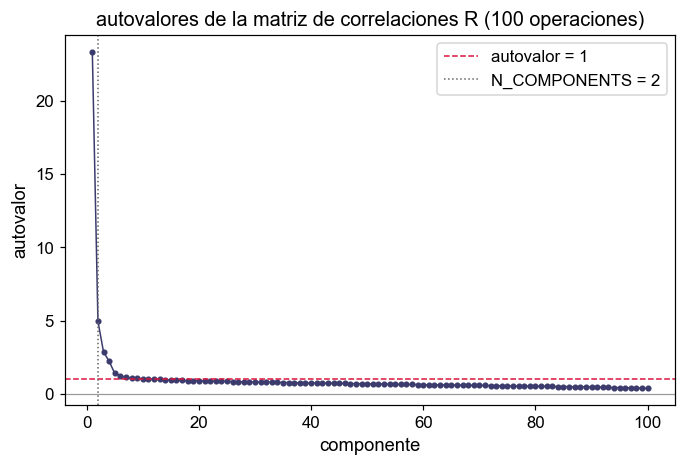

In [20]:
# =============================================================================
# 8 (apéndice). Autovalores de la matriz de correlaciones
# =============================================================================
# Cuánta varianza de R capturaría cada dimensión si el MDS pudiera usar todas
# las que hicieran falta, antes de forzarlo a quedarse con 2 (N_COMPONENTS). Si
# los dos primeros autovalores ya concentran casi toda la varianza, 2D es una
# aproximación razonable; si no, el mapa está comprimiendo estructura real que
# vive en más dimensiones de las que se están mirando.
#
# R es pairwise-complete: cada r_ij sale de un subconjunto distinto de alumnos,
# así que a diferencia de una matriz de correlaciones de toda la vida NO está
# garantizado que sea semidefinida positiva. Autovalores negativos no minúsculos
# serían ese síntoma, no un error de cálculo.
assert not np.isnan(R).any(), \
    "R tiene NaN fuera de la diagonal (algún par con n_ij < 3): revisar antes de diagonalizar"

eigvals = np.linalg.eigvalsh(R)[::-1]        # R es simétrica; orden descendente
var_exp = eigvals / eigvals.sum()
n_neg = int((eigvals < -1e-8).sum())

print(f"autovalores de R ({nf} operaciones del mapa principal):")
for k, (lam, pct) in enumerate(zip(eigvals, var_exp), start=1):
    print(f"  {k:>3}: {lam:9.4f}   {100 * pct:5.1f}% de la varianza · "
          f"acumulado {100 * var_exp[:k].sum():5.1f}%")
print(f"\nautovalores negativos: {n_neg} (mínimo {eigvals.min():+.4f}) -- "
      f"{'esperable, R no es psd por construcción pairwise-complete' if n_neg else 'ninguno'}")
print(f"con {N_COMPONENTS} dimensiones (las que usa el MDS) se cubre el "
      f"{100 * var_exp[:N_COMPONENTS].sum():.1f}% de la varianza de R")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.plot(range(1, nf + 1), eigvals, marker="o", ms=3, lw=1, color="#3b3b6d")
ax.axhline(0, color="0.6", lw=0.8)
ax.axhline(1, color="crimson", lw=1, ls="--", label="autovalor = 1")
ax.axvline(N_COMPONENTS, color="0.4", lw=1, ls=":",
           label=f"N_COMPONENTS = {N_COMPONENTS}")
ax.set_xlabel("componente"); ax.set_ylabel("autovalor")
ax.set_title(f"autovalores de la matriz de correlaciones R ({nf} operaciones)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS / "a998_mds_autovalores.png", dpi=150)
fig.savefig(PLOTS / "a998_mds_autovalores.pdf")
plt.show()
